# Figure 1 

177


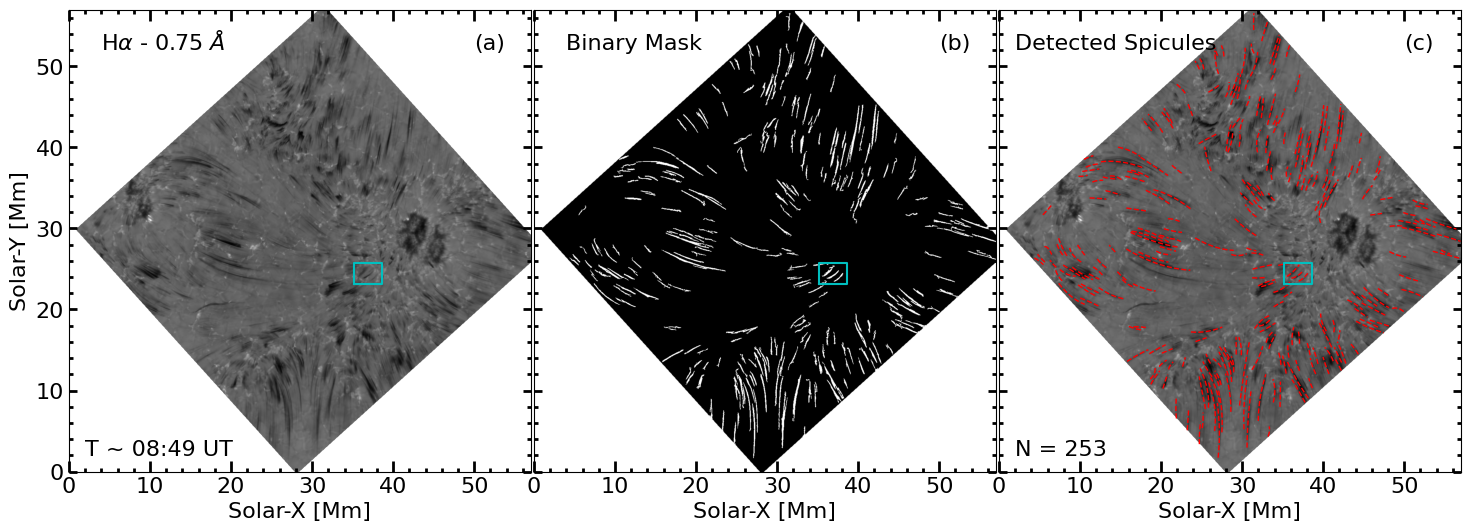

Detected 253 spicules.
Lengths (Mm): mean=2.469, median=2.123
Widths  (Mm): mean=0.266, median=0.236
[2.54581175 2.40131846] [0.73911723 0.90524339] 0.22017314152442935
[1.80512824 1.6644613 ] [0.98801042 1.20726273] 0.26049714607186253
[1.31326385 1.06048765] [1.45784178 1.72516859] 0.36791226356826684


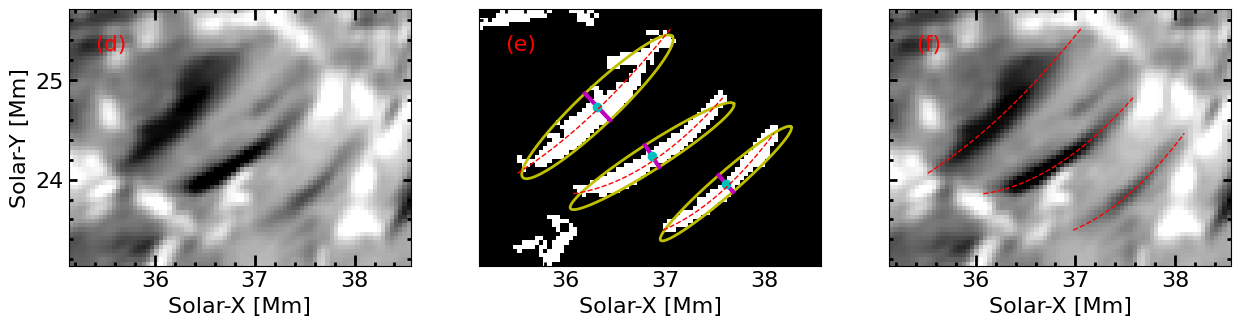

In [18]:

"""
Optimized spicule detection pipeline with line-by-line comments.

Usage:
    - Set `FILENAME` to your FITS file path.
    - Optionally tune parameters in the `Params` dataclass.
    - Call `process_frame(...)` to run detection on a single frame index.
"""

import numpy as np                                     # numeric operations
import matplotlib.pyplot as plt                        # plotting
from astropy.io import fits                            # read FITS files
from scipy.interpolate import interp1d                 # (kept if you need wavelength interpolation)
from skimage import exposure, morphology               # contrast enhancement + morphology
from skimage.filters import frangi, threshold_otsu     # ridge detection + thresholding
from skimage.measure import label, regionprops         # connected component analysis
from skimage.morphology import disk                     # structuring element helper
from scipy.ndimage import gaussian_filter               # optional smoothing
from scipy.integrate import simpson                     # numeric integration for arc length
from scipy.stats import gaussian_kde                    # KDE for distributions
from scipy.signal import find_peaks                     # detect peaks in KDE
import warnings                                         # to suppress runtime warnings
from skimage.morphology import skeletonize
from scipy.ndimage import distance_transform_edt
import numpy as np
import matplotlib.pyplot as plt
from powerlaw import Fit
from scipy.optimize import curve_fit


plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True

# Set minor tick width and length
plt.rcParams['xtick.minor.width'] = 2
plt.rcParams['ytick.minor.width'] = 2
plt.rcParams['xtick.minor.size'] = 3
plt.rcParams['ytick.minor.size'] = 3

# Set minor tick width and length
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['ytick.major.width'] = 2
plt.rcParams['xtick.major.size'] = 8
plt.rcParams['ytick.major.size'] = 6


FILENAME = '/media/ravi/Expansion/30-04-2020/PCDinterpolated_ha_6_206.fits'  
spec_indx=6
FRAME_INDEX=14

WAVELIST = np.array([656.12500,656.15002,656.17499,656.20001,656.22498,
                     656.25000,656.27502,656.29999,656.32501,656.34998,
                     656.37500,656.40002,656.42499,656.45001,656.47498]) 
dt=29.229

# physical/scale conversion
plate_scale = 0.0591                # arcsec/pixel (user-provided)
conversion_factor = plate_scale * 0.725  # Mm/pixel conversion factor (user-provided)

plt.rcParams['font.size']=16

# ---------------------------
# === PROCESSING PARAMETERS
# ---------------------------
class Params:
    """Container with tunable parameters for detection and filtering."""
    # preprocessing
    equalize_clip = 0.012             # clip limit for CLAHE
    equalize_kernel = (60, 60)       # CLAHE kernel (height, width) in pixels
    smooth_sigma = 0.8               # Gaussian smoothing (small) before Frangi

    # frangi / ridge detection
    frangi_sigmas = np.arange(1, 2)  # range of scales to test
    frangi_black_ridges = False      # spicules appear bright on inverted image -> False
    frangi_alpha = 0.2
    frangi_beta = 0.18
    frangi_gamma = 10.0

    # binary postprocessing
    otsu_factor = 0.07                # your threshold_factor

    # region filtering (units: pixels)
    min_length = 30
    max_length = 200
    min_width = 4
    max_width = 15
    min_elongation = 5.0
    curvature_threshold = 0.3
    show_plots = True

P = Params()  

# ---------------------------
# === UTILITY / HELPER FUNCs
# ---------------------------
def load_fits_cube(fname):
    """Load FITS data from `fname` and return numpy array (no header)."""
    # read FITS data; fits.getdata returns a numpy array
    cube = fits.getdata(fname)
    return cube

def normalize_and_invert(image):
    """Normalize image to [0,1], apply CLAHE, and invert (so bright ridges become dark for Frangi when black_ridges=False)."""
    # compute nan mask and operate ignoring NaNs
    nan_mask = np.isnan(image)                              # True where data is NaN
    img = image.copy()                                      # avoid modifying original
    # replace NaNs by min for normalization but keep mask to reassign NaNs later
    finite_mask = ~nan_mask
    if not np.any(finite_mask):
        return img, nan_mask                                # empty frame guard

    img_min = np.nanmin(img)                                # minimum value over finite pixels
    img_max = np.nanmax(img)                                # maximum value
    if img_max == img_min:
        # avoid division by zero for flat images
        norm = np.zeros_like(img, dtype=float)
    else:
        norm = (img - img_min) / (img_max - img_min)        # scale to [0,1]
    # apply CLAHE (adaptive histogram equalization)    
    norm_clahe = exposure.equalize_adapthist(norm, clip_limit=P.equalize_clip, kernel_size=P.equalize_kernel)
    # invert image so bright filaments -> dark (because we set frangi_black_ridges=False below)
    inverted = 1.0 - norm_clahe
    # restore NaNs to mask positions
    inverted[nan_mask] = np.nan
    return inverted, nan_mask

def compute_frangi(inverted_image):
    """Run Frangi vesselness to enhance thin linear structures (spicules)."""
    # replace NaNs by local median for frangi to avoid errors (frangi doesn't accept NaNs)
    nan_mask = np.isnan(inverted_image)
    img = inverted_image.copy()
    if np.any(nan_mask):
        # replace NaNs by a small local smoothing value (median of finite pixels)
        img[nan_mask] = np.nanmedian(img)
    # optional small Gaussian smoothing to stabilize frangi
    img_smooth = gaussian_filter(img, sigma=P.smooth_sigma)
    # run frangi at specified sigmas; faster than using 1..19
    vesselness = frangi(img_smooth,
                        sigmas=P.frangi_sigmas,
                        black_ridges=P.frangi_black_ridges,
                        alpha=P.frangi_alpha,
                        beta=P.frangi_beta,
                        gamma=P.frangi_gamma)
    return vesselness

def binarize_and_clean(vesselness, nan_mask):
    """Threshold vesselness via Otsu*factor, close gaps, remove small objects."""
    # calculate Otsu threshold on finite pixels only
    finite_mask = ~nan_mask
    if not np.any(finite_mask):
        # return empty mask if no finite pixels
        return np.zeros_like(vesselness, dtype=bool)
    base_thresh = threshold_otsu(vesselness[finite_mask])   # Otsu threshold
    thresh = base_thresh * P.otsu_factor                    # scaled threshold
    binary = vesselness > thresh                            # boolean mask
    binary[nan_mask] = False
    return binary


def filter_regions_by_geometry(labeled_img):
    """Filter connected components in `labeled_img` by major/minor/elongation constraints."""
    filtered_mask = np.zeros_like(labeled_img, dtype=bool)   # initialize
    for region in regionprops(labeled_img):
        major = region.major_axis_length
        minor = region.minor_axis_length
        # skip degenerate cases
        if minor == 0:
            continue
        elongation = major / minor
        # apply geometric thresholds
        if P.min_length <= major <= P.max_length and P.min_width <= minor <= P.max_width and elongation >= P.min_elongation:
            filtered_mask[labeled_img == region.label] = True
    return filtered_mask


def fit_spicule_curve(coords):
    """
    Fit a quadratic curve to coordinates, compute arc length and curvature rejection.
    coords: Nx2 array of (row, col) where row=y, col=x
    Returns (length_pixels, width_pixels, x_fit, y_fit) or None if rejected.
    """
    # coordinates as arrays
    y = coords[:, 0].astype(float)   # row index
    x = coords[:, 1].astype(float)   # column index

    # decide whether x = f(y) or y = f(x) (select the direction with larger span)
    span_y = y.max() - y.min()
    span_x = x.max() - x.min()

    try:
        if span_y >= span_x:
            # fit x as a function of y
            coeffs = np.polyfit(y, x, deg=2)                # quadratic fit x(y)
            y_fit = np.linspace(y.min(), y.max(), 200)      # dense sampling along y
            x_fit = np.polyval(coeffs, y_fit)               # fitted x values
            # derivatives of polynomial: first and second derivative (analytic)
            d1 = np.polyval(np.polyder(coeffs), y_fit)     # dx/dy
            d2 = np.polyval(np.polyder(coeffs, 2), y_fit)  # d2x/dy2
            # curvature for parametric curve (x(y), y): κ = |d2x/dy2| / (1 + (dx/dy)^2)^(3/2)
            curvature = np.abs(d2) / (1.0 + d1**2)**1.5
            max_curv = curvature.max()
            if max_curv > P.curvature_threshold:
                return None
            # arc length integral for x(y): ∫ sqrt(1 + (dx/dy)^2) dy
            integrand = np.sqrt(1.0 + d1**2)
            length_pixels = simpson(integrand, y_fit)
            # use minor axis as width candidate (we do not have minor here; caller will set)
            return length_pixels, x_fit, y_fit
        else:
            # fit y as a function of x
            coeffs = np.polyfit(x, y, deg=2)                # quadratic fit y(x)
            x_fit = np.linspace(x.min(), x.max(), 200)      # dense sampling along x
            y_fit = np.polyval(coeffs, x_fit)               # fitted y values
            d1 = np.polyval(np.polyder(coeffs), x_fit)      # dy/dx
            d2 = np.polyval(np.polyder(coeffs, 2), x_fit)   # d2y/dx2
            curvature = np.abs(d2) / (1.0 + d1**2)**1.5
            max_curv = curvature.max()
            if max_curv > P.curvature_threshold:
                return None
            integrand = np.sqrt(1.0 + d1**2)
            length_pixels = simpson(integrand, x_fit)
            return length_pixels, x_fit, y_fit
    except np.linalg.LinAlgError:
        return None

def process_frame(cube, frame_index=FRAME_INDEX):
    """
    Process a single frame from the cube. Returns lists of spicule lengths and widths (in Mm)
    plus an output binary mask for visualization.
    """
    # get the requested 3D frame (matching your cube[kk] indexing)
    data_cube = cube[frame_index]               # e.g. cube[7]
    # select spectral slice index you used previously (data_cube[6] in original)
    spectral_idx = spec_indx
    data = data_cube[spectral_idx]              # 2D image (ny, nx)
    # create NaN mask for later
    nan_mask = np.isnan(data)
    # normalize + enhance + invert (returns image and mask)
    inverted, nan_mask = normalize_and_invert(data)
    # compute vesselness (frangi)
    vessel = compute_frangi(inverted)
    # threshold and clean
    cleaned = binarize_and_clean(vessel, nan_mask)
    # label after cleaning
    labeled = label(cleaned)
    # geometry filtering by major/minor/elongation
    filtered_mask = filter_regions_by_geometry(labeled)
    # final label of filtered objects
    final_labeled = label(filtered_mask)
    regions = regionprops(final_labeled)

    spicule_lengths_px = []                     # store lengths in pixels
    spicule_widths_px = []                      # store widths in pixels (major/minor from regionprops)
    fitted_lines = []                            # store for plotting
    widths_all=[]

    # iterate regions to do curve fit and curvature check
    for region in regions:
        coords = region.coords                    # pixel coordinates of the region
        fit_res = fit_spicule_curve(coords)
        length_px, x_fit00, y_fit00 = fit_res
        y0, x0 = region.centroid
        theta = region.orientation
        a = region.major_axis_length / 2
        b = region.minor_axis_length / 2
    
        t = np.linspace(0, 2*np.pi, 200)
        x_ellipse = x0 + a*np.cos(t)*np.cos(theta) - b*np.sin(t)*np.sin(theta)
        y_ellipse = y0 + a*np.cos(t)*np.sin(theta) + b*np.sin(t)*np.cos(theta)

        # Use curve-based orientation
        dx = x_fit00[-1] - x_fit00[0]
        dy = y_fit00[-1] - y_fit00[0]
        theta = np.arctan2(dy, dx)
        
        # Keep regionprops lengths
        a = region.major_axis_length / 2
        b = region.minor_axis_length / 2
        y0, x0 = region.centroid
        
        t = np.linspace(0, 2*np.pi, 200)
        
        x_ellipse = x0 + a*np.cos(t)*np.cos(theta) - b*np.sin(t)*np.sin(theta)
        y_ellipse = y0 + a*np.cos(t)*np.sin(theta) + b*np.sin(t)*np.cos(theta)
        
        # Minor axis
        dx_m = -np.sin(theta)
        dy_m =  np.cos(theta)
        
        x_minor = np.array([x0 - b*dx_m, x0 + b*dx_m])
        y_minor = np.array([y0 - b*dy_m, y0 + b*dy_m])

        minor = np.sqrt((x_minor[1]-x_minor[0])**2+(y_minor[1]-y_minor[0])**2)
        if minor == 0:
            continue
        # obtain fitted length and curve points
        fit_res = fit_spicule_curve(coords)
        if fit_res is None:
            continue
        # fit_res returns (length_pixels, x_fit, y_fit)
        length_px, x_fit00, y_fit00 = fit_res
        # apply the additional geometry width filter (region.minor_axis_length)
        if not (P.min_width <= minor <= P.max_width):
            continue
        # success: append results
        spicule_lengths_px.append(length_px)
        mask_region = (final_labeled == region.label)
        #length_px, width_px,widths_all_px = measure_spicule_length_width(mask_region)
        spicule_widths_px.append(minor)
        fitted_lines.append((x_fit00, y_fit00))

    # convert to numpy arrays and to Mm units
    lengths_px = np.array(spicule_lengths_px)
    widths_px = np.array(spicule_widths_px)
    lengths_Mm = lengths_px * conversion_factor
    widths_Mm = widths_px * conversion_factor

    if P.show_plots:
        # Top row: original, mask, overlay
        
        plt.subplots(1,3,figsize=(18, 6),sharex=True,sharey=True)
        plt.subplots_adjust(hspace=0.0,wspace=0.0)
        plt.subplot(1, 3, 1)
        plt.imshow(data, cmap='gray', origin='lower',extent=[0,1330*0.0591*0.725,0,1330*0.0591*0.725])
        nan_region=np.isnan(data)
        plt.xlabel('Solar-X [Mm]')
        plt.ylabel('Solar-Y [Mm]')
        plt.text(4, 52, r'H$\alpha$ - 0.75 $\AA$')
        plt.text(2,2,'T ~'+' 08:49 UT')
        plt.text(50,52,'(a)')
        plt.plot([820*0.0591*0.725,820*0.0591*0.725,900*0.0591*0.725,900*0.0591*0.725,820*0.0591*0.725],[540*0.0591*0.725,600*0.0591*0.725,600*0.0591*0.725,540*0.0591*0.725,540*0.0591*0.725],'c')
        #plt.tick_params(axis='x', labelbottom=False)

        #plt.title('Original')

        plt.subplot(1, 3, 2)
        filtered_mask[nan_mask]=np.nan
        plt.imshow(filtered_mask, cmap='gray', origin='lower',extent=[0,1330*0.0591*0.725,0,1330*0.0591*0.725])
        plt.xlabel('Solar-X [Mm]')
        plt.text(4, 52, 'Binary Mask')
        #plt.title('Filtered Mask')
        #plt.tick_params(axis='x', labelbottom=False)
        plt.text(50,52,'(b)')
        plt.plot([820*0.0591*0.725,820*0.0591*0.725,900*0.0591*0.725,900*0.0591*0.725,820*0.0591*0.725],[540*0.0591*0.725,600*0.0591*0.725,600*0.0591*0.725,540*0.0591*0.725,540*0.0591*0.725],'c')
        
        plt.subplot(1, 3, 3)
        plt.imshow(data, cmap='gray', origin='lower',extent=[0,1330*0.0591*0.725,0,1330*0.0591*0.725])
        plt.xlabel('Solar-X [Mm]')
        for (x_fit, y_fit) in fitted_lines:
            # plotting fitted curve (x_fit, y_fit) as red dashed
            plt.plot(x_fit*0.0591*0.725, y_fit*0.0591*0.725, '--r', linewidth=1)
        plt.text(2,52, 'Detected Spicules')
        #plt.axis('off')   
        #plt.tick_params(axis='x', labelbottom=False)
        plt.text(2,2,'N = '+str(len(lengths_Mm)))
        plt.text(50,52,'(c)')
        plt.plot([820*0.0591*0.725,820*0.0591*0.725,900*0.0591*0.725,900*0.0591*0.725,820*0.0591*0.725],[540*0.0591*0.725,600*0.0591*0.725,600*0.0591*0.725,540*0.0591*0.725,540*0.0591*0.725],'c')
        plt.savefig('/media/ravi/Expansion/30-04-2020/Again_submit_Power_law/figures/Halpha_wing_spicule_detection.png',dpi=300,bbox_inches='tight')
        plt.show()

    return lengths_Mm, widths_Mm, filtered_mask,widths_px,lengths_px,regions,widths_all,vessel,fitted_lines


if __name__ == "__main__":
    warnings.filterwarnings("ignore", category=RuntimeWarning)
    cube = load_fits_cube(FILENAME)
    for i in range(177,178):
        print(i)
        lengths, widths, mask ,widths_px,lengths_px,regions,widths_all,vessel,fitted_lines= process_frame(cube, frame_index=i)
        print(f"Detected {len(lengths)} spicules.")
        if len(lengths) > 0:
            print(f"Lengths (Mm): mean={np.mean(lengths):.3f}, median={np.median(lengths):.3f}")
            print(f"Widths  (Mm): mean={np.mean(widths):.3f}, median={np.median(widths):.3f}")


plt.subplots(1,3,figsize=(15,10),sharex=True,sharey=True)
plt.subplot(131)
plt.imshow(cube[i,6],origin='lower',extent=[0,1330*0.0591*0.725,0,1330*0.0591*0.725],vmax=np.nanpercentile(cube[i,6],98),vmin=np.nanpercentile(cube[i,6],3),cmap='gray')
plt.xlabel('Solar-X [Mm]')
plt.ylabel('Solar-Y [Mm]')
plt.text(35.4,25.3,'(d)',color='r')
plt.subplot(132)
plt.imshow(mask,origin='lower',extent=[0,1330*0.0591*0.725,0,1330*0.0591*0.725],cmap='gray')
plt.xlabel('Solar-X [Mm]')
plt.text(35.4,25.3,'(e)',color='r')
plt.subplot(133)
plt.imshow(cube[i,6],origin='lower',extent=[0,1330*0.0591*0.725,0,1330*0.0591*0.725],vmax=np.nanpercentile(cube[i,6],98),vmin=np.nanpercentile(cube[i,6],3),cmap='gray')
plt.xlim(820*0.0591*0.725,900*0.0591*0.725)
plt.ylim(540*0.0591*0.725,600*0.0591*0.725)
plt.xlabel('Solar-X [Mm]')
plt.text(35.4,25.3,'(f)',color='r')
final_labeled = label(mask[540:600,820:900])
region = regionprops(final_labeled)

nos=[1,2,3]

for ii in range(len(nos)): 
    plt.subplot(133)
    coords = region[nos[ii]].coords
    fit_res = fit_spicule_curve(coords)
    length_px, x_fit, y_fit = fit_res
    plt.plot((x_fit+820)*0.0591*0.725, (y_fit+540)*0.0591*0.725, '--r', linewidth=1)

    
    y0, x0 = region[nos[ii]].centroid
    theta = region[nos[ii]].orientation
    a = region[nos[ii]].major_axis_length / 2
    b = region[nos[ii]].minor_axis_length / 2

    t = np.linspace(0, 2*np.pi, 200)
    x_ellipse = x0 + a*np.cos(t)*np.cos(theta) - b*np.sin(t)*np.sin(theta)
    y_ellipse = y0 + a*np.cos(t)*np.sin(theta) + b*np.sin(t)*np.cos(theta)

    
    # Use curve-based orientation
    dx = x_fit[-1] - x_fit[0]
    dy = y_fit[-1] - y_fit[0]
    theta = np.arctan2(dy, dx)
    
    # Keep regionprops lengths
    a = region[nos[ii]].major_axis_length / 2
    b = region[nos[ii]].minor_axis_length / 2
    y0, x0 = region[nos[ii]].centroid
    
    t = np.linspace(0, 2*np.pi, 200)
    
    x_ellipse = x0 + a*np.cos(t)*np.cos(theta) - b*np.sin(t)*np.sin(theta)
    y_ellipse = y0 + a*np.cos(t)*np.sin(theta) + b*np.sin(t)*np.cos(theta)
    
    # Minor axis
    dx_m = -np.sin(theta)
    dy_m =  np.cos(theta)
    
    x_minor = np.array([x0 - b*dx_m, x0 + b*dx_m])
    y_minor = np.array([y0 - b*dy_m, y0 + b*dy_m])
    
    plt.subplot(132)
    plt.plot((x_ellipse+820)*0.0591*0.725, (y_ellipse+540)*0.0591*0.725, 'y', lw=2)
    plt.plot((x_minor+820)*0.0591*0.725, (y_minor+540)*0.0591*0.725, 'm-', lw=3)
    plt.plot((x0+820)*0.0591*0.725, (y0+540)*0.0591*0.725, 'co')
    plt.plot((x_fit+820)*0.0591*0.725, (y_fit+540)*0.0591*0.725, '--r', linewidth=1)
    print(x_minor*0.0591*0.725,y_minor*0.0591*0.725,np.sqrt((y_minor[1]-y_minor[0])**2+(x_minor[1]-x_minor[0])**2)*0.0591*0.725)

plt.savefig('/media/ravi/Expansion/30-04-2020/Again_submit_Power_law/figures/Halpha_wing_spicule_detection_FOV.png',dpi=300,bbox_inches='tight')




# Figure 5

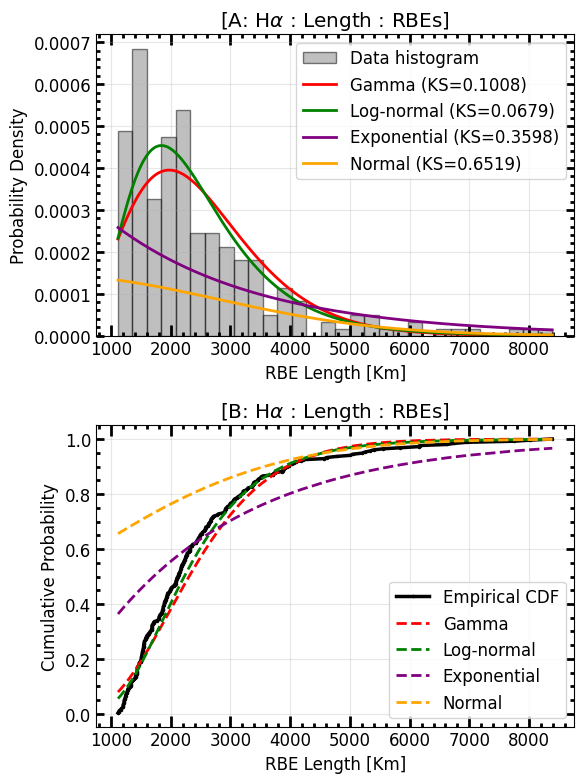


Log-Normal Fit Results : RBE Length [Km]
mu      = 7.7078
sigma   = 0.4342
KS      = 0.0679



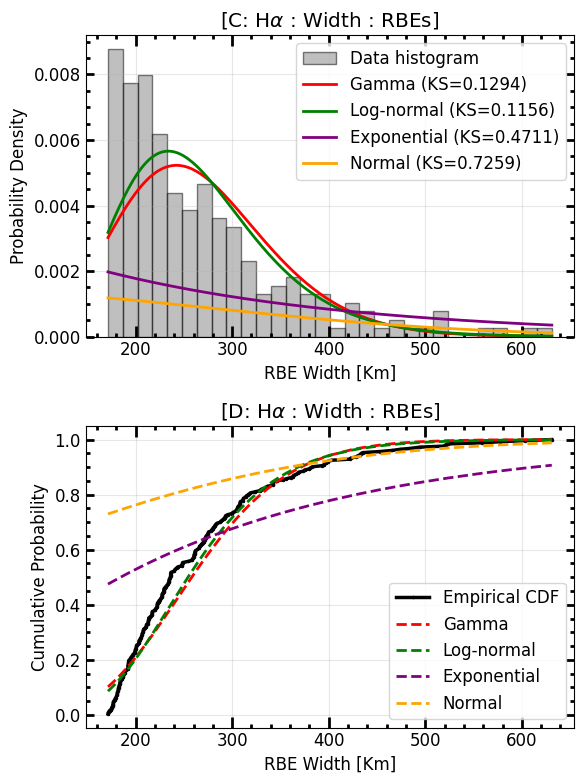


Log-Normal Fit Results : RBE Width [Km]
mu      = 5.5382
sigma   = 0.2891
KS      = 0.1156



In [1]:

"""
Optimized spicule detection pipeline with line-by-line comments.

Usage:
    - Set `FILENAME` to your FITS file path.
    - Optionally tune parameters in the `Params` dataclass.
    - Call `process_frame(...)` to run detection on a single frame index.
"""

import numpy as np                                     # numeric operations
import matplotlib.pyplot as plt                        # plotting
from astropy.io import fits                            # read FITS files
from scipy.interpolate import interp1d                 # (kept if you need wavelength interpolation)
from skimage import exposure, morphology               # contrast enhancement + morphology
from skimage.filters import frangi, threshold_otsu     # ridge detection + thresholding
from skimage.measure import label, regionprops         # connected component analysis
from skimage.morphology import disk                     # structuring element helper
from scipy.ndimage import gaussian_filter               # optional smoothing
from scipy.integrate import simpson                     # numeric integration for arc length
from scipy.stats import gaussian_kde                    # KDE for distributions
from scipy.signal import find_peaks                     # detect peaks in KDE
import warnings                                         # to suppress runtime warnings
from skimage.morphology import skeletonize
from scipy.ndimage import distance_transform_edt
import numpy as np
import matplotlib.pyplot as plt
from powerlaw import Fit
from scipy.optimize import curve_fit


plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True

# Set minor tick width and length
plt.rcParams['xtick.minor.width'] = 2
plt.rcParams['ytick.minor.width'] = 2
plt.rcParams['xtick.minor.size'] = 3
plt.rcParams['ytick.minor.size'] = 3

# Set minor tick width and length
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['ytick.major.width'] = 2
plt.rcParams['xtick.major.size'] = 8
plt.rcParams['ytick.major.size'] = 6


FILENAME = '/media/ravi/Expansion/30-04-2020/PCDinterpolated_ha_6_206.fits'  
spec_indx=6
FRAME_INDEX=14

WAVELIST = np.array([656.12500,656.15002,656.17499,656.20001,656.22498,
                     656.25000,656.27502,656.29999,656.32501,656.34998,
                     656.37500,656.40002,656.42499,656.45001,656.47498]) 
dt=29.229

# physical/scale conversion
plate_scale = 0.0591                # arcsec/pixel (user-provided)
conversion_factor = plate_scale * 0.725  # Mm/pixel conversion factor (user-provided)

plt.rcParams['font.size']=16

# ---------------------------
# === PROCESSING PARAMETERS
# ---------------------------
class Params:
    """Container with tunable parameters for detection and filtering."""
    # preprocessing
    equalize_clip = 0.012             # clip limit for CLAHE
    equalize_kernel = (60, 60)       # CLAHE kernel (height, width) in pixels
    smooth_sigma = 0.8               # Gaussian smoothing (small) before Frangi

    # frangi / ridge detection
    frangi_sigmas = np.arange(1, 2)  # range of scales to test
    frangi_black_ridges = False      # spicules appear bright on inverted image -> False
    frangi_alpha = 0.2
    frangi_beta = 0.18
    frangi_gamma = 10.0

    # binary postprocessing
    otsu_factor = 0.07                # your threshold_factor

    # region filtering (units: pixels)
    min_length = 30
    max_length = 200
    min_width = 4
    max_width = 15
    min_elongation = 5.0
    curvature_threshold = 0.3
    show_plots = False

P = Params()  

# ---------------------------
# === UTILITY / HELPER FUNCs
# ---------------------------
def load_fits_cube(fname):
    """Load FITS data from `fname` and return numpy array (no header)."""
    # read FITS data; fits.getdata returns a numpy array
    cube = fits.getdata(fname)
    return cube

def normalize_and_invert(image):
    """Normalize image to [0,1], apply CLAHE, and invert (so bright ridges become dark for Frangi when black_ridges=False)."""
    # compute nan mask and operate ignoring NaNs
    nan_mask = np.isnan(image)                              # True where data is NaN
    img = image.copy()                                      # avoid modifying original
    # replace NaNs by min for normalization but keep mask to reassign NaNs later
    finite_mask = ~nan_mask
    if not np.any(finite_mask):
        return img, nan_mask                                # empty frame guard

    img_min = np.nanmin(img)                                # minimum value over finite pixels
    img_max = np.nanmax(img)                                # maximum value
    if img_max == img_min:
        # avoid division by zero for flat images
        norm = np.zeros_like(img, dtype=float)
    else:
        norm = (img - img_min) / (img_max - img_min)        # scale to [0,1]
    # apply CLAHE (adaptive histogram equalization)    
    norm_clahe = exposure.equalize_adapthist(norm, clip_limit=P.equalize_clip, kernel_size=P.equalize_kernel)
    # invert image so bright filaments -> dark (because we set frangi_black_ridges=False below)
    inverted = 1.0 - norm_clahe
    # restore NaNs to mask positions
    inverted[nan_mask] = np.nan
    return inverted, nan_mask

def compute_frangi(inverted_image):
    """Run Frangi vesselness to enhance thin linear structures (spicules)."""
    # replace NaNs by local median for frangi to avoid errors (frangi doesn't accept NaNs)
    nan_mask = np.isnan(inverted_image)
    img = inverted_image.copy()
    if np.any(nan_mask):
        # replace NaNs by a small local smoothing value (median of finite pixels)
        img[nan_mask] = np.nanmedian(img)
    # optional small Gaussian smoothing to stabilize frangi
    img_smooth = gaussian_filter(img, sigma=P.smooth_sigma)
    # run frangi at specified sigmas; faster than using 1..19
    vesselness = frangi(img_smooth,
                        sigmas=P.frangi_sigmas,
                        black_ridges=P.frangi_black_ridges,
                        alpha=P.frangi_alpha,
                        beta=P.frangi_beta,
                        gamma=P.frangi_gamma)
    return vesselness

def binarize_and_clean(vesselness, nan_mask):
    """Threshold vesselness via Otsu*factor, close gaps, remove small objects."""
    # calculate Otsu threshold on finite pixels only
    finite_mask = ~nan_mask
    if not np.any(finite_mask):
        # return empty mask if no finite pixels
        return np.zeros_like(vesselness, dtype=bool)
    base_thresh = threshold_otsu(vesselness[finite_mask])   # Otsu threshold
    thresh = base_thresh * P.otsu_factor                    # scaled threshold
    binary = vesselness > thresh                            # boolean mask
    binary[nan_mask] = False
    return binary


def filter_regions_by_geometry(labeled_img):
    """Filter connected components in `labeled_img` by major/minor/elongation constraints."""
    filtered_mask = np.zeros_like(labeled_img, dtype=bool)   # initialize
    for region in regionprops(labeled_img):
        major = region.major_axis_length
        minor = region.minor_axis_length
        # skip degenerate cases
        if minor == 0:
            continue
        elongation = major / minor
        # apply geometric thresholds
        if P.min_length <= major <= P.max_length and P.min_width <= minor <= P.max_width and elongation >= P.min_elongation:
            filtered_mask[labeled_img == region.label] = True
    return filtered_mask


def fit_spicule_curve(coords):
    """
    Fit a quadratic curve to coordinates, compute arc length and curvature rejection.
    coords: Nx2 array of (row, col) where row=y, col=x
    Returns (length_pixels, width_pixels, x_fit, y_fit) or None if rejected.
    """
    # coordinates as arrays
    y = coords[:, 0].astype(float)   # row index
    x = coords[:, 1].astype(float)   # column index

    # decide whether x = f(y) or y = f(x) (select the direction with larger span)
    span_y = y.max() - y.min()
    span_x = x.max() - x.min()

    try:
        if span_y >= span_x:
            # fit x as a function of y
            coeffs = np.polyfit(y, x, deg=2)                # quadratic fit x(y)
            y_fit = np.linspace(y.min(), y.max(), 200)      # dense sampling along y
            x_fit = np.polyval(coeffs, y_fit)               # fitted x values
            # derivatives of polynomial: first and second derivative (analytic)
            d1 = np.polyval(np.polyder(coeffs), y_fit)     # dx/dy
            d2 = np.polyval(np.polyder(coeffs, 2), y_fit)  # d2x/dy2
            # curvature for parametric curve (x(y), y): κ = |d2x/dy2| / (1 + (dx/dy)^2)^(3/2)
            curvature = np.abs(d2) / (1.0 + d1**2)**1.5
            max_curv = curvature.max()
            if max_curv > P.curvature_threshold:
                return None
            # arc length integral for x(y): ∫ sqrt(1 + (dx/dy)^2) dy
            integrand = np.sqrt(1.0 + d1**2)
            length_pixels = simpson(integrand, y_fit)
            # use minor axis as width candidate (we do not have minor here; caller will set)
            return length_pixels, x_fit, y_fit
        else:
            # fit y as a function of x
            coeffs = np.polyfit(x, y, deg=2)                # quadratic fit y(x)
            x_fit = np.linspace(x.min(), x.max(), 200)      # dense sampling along x
            y_fit = np.polyval(coeffs, x_fit)               # fitted y values
            d1 = np.polyval(np.polyder(coeffs), x_fit)      # dy/dx
            d2 = np.polyval(np.polyder(coeffs, 2), x_fit)   # d2y/dx2
            curvature = np.abs(d2) / (1.0 + d1**2)**1.5
            max_curv = curvature.max()
            if max_curv > P.curvature_threshold:
                return None
            integrand = np.sqrt(1.0 + d1**2)
            length_pixels = simpson(integrand, x_fit)
            return length_pixels, x_fit, y_fit
    except np.linalg.LinAlgError:
        return None

def process_frame(cube, frame_index=FRAME_INDEX):
    """
    Process a single frame from the cube. Returns lists of spicule lengths and widths (in Mm)
    plus an output binary mask for visualization.
    """
    # get the requested 3D frame (matching your cube[kk] indexing)
    data_cube = cube[frame_index]               # e.g. cube[7]
    # select spectral slice index you used previously (data_cube[6] in original)
    spectral_idx = spec_indx
    data = data_cube[spectral_idx]              # 2D image (ny, nx)
    # create NaN mask for later
    nan_mask = np.isnan(data)
    # normalize + enhance + invert (returns image and mask)
    inverted, nan_mask = normalize_and_invert(data)
    # compute vesselness (frangi)
    vessel = compute_frangi(inverted)
    # threshold and clean
    cleaned = binarize_and_clean(vessel, nan_mask)
    # label after cleaning
    labeled = label(cleaned)
    # geometry filtering by major/minor/elongation
    filtered_mask = filter_regions_by_geometry(labeled)
    # final label of filtered objects
    final_labeled = label(filtered_mask)
    regions = regionprops(final_labeled)

    spicule_lengths_px = []                     # store lengths in pixels
    spicule_widths_px = []                      # store widths in pixels (major/minor from regionprops)
    fitted_lines = []                            # store for plotting
    widths_all=[]

    # iterate regions to do curve fit and curvature check
    for region in regions:
        coords = region.coords                    # pixel coordinates of the region
        fit_res = fit_spicule_curve(coords)
        length_px, x_fit00, y_fit00 = fit_res
        y0, x0 = region.centroid
        theta = region.orientation
        a = region.major_axis_length / 2
        b = region.minor_axis_length / 2
    
        t = np.linspace(0, 2*np.pi, 200)
        x_ellipse = x0 + a*np.cos(t)*np.cos(theta) - b*np.sin(t)*np.sin(theta)
        y_ellipse = y0 + a*np.cos(t)*np.sin(theta) + b*np.sin(t)*np.cos(theta)

        # Use curve-based orientation
        dx = x_fit00[-1] - x_fit00[0]
        dy = y_fit00[-1] - y_fit00[0]
        theta = np.arctan2(dy, dx)
        
        # Keep regionprops lengths
        a = region.major_axis_length / 2
        b = region.minor_axis_length / 2
        y0, x0 = region.centroid
        
        t = np.linspace(0, 2*np.pi, 200)
        
        x_ellipse = x0 + a*np.cos(t)*np.cos(theta) - b*np.sin(t)*np.sin(theta)
        y_ellipse = y0 + a*np.cos(t)*np.sin(theta) + b*np.sin(t)*np.cos(theta)
        
        # Minor axis
        dx_m = -np.sin(theta)
        dy_m =  np.cos(theta)
        
        x_minor = np.array([x0 - b*dx_m, x0 + b*dx_m])
        y_minor = np.array([y0 - b*dy_m, y0 + b*dy_m])

        minor = np.sqrt((x_minor[1]-x_minor[0])**2+(y_minor[1]-y_minor[0])**2)
        if minor == 0:
            continue
        # obtain fitted length and curve points
        fit_res = fit_spicule_curve(coords)
        if fit_res is None:
            continue
        # fit_res returns (length_pixels, x_fit, y_fit)
        length_px, x_fit00, y_fit00 = fit_res
        # apply the additional geometry width filter (region.minor_axis_length)
        if not (P.min_width <= minor <= P.max_width):
            continue
        # success: append results
        spicule_lengths_px.append(length_px)
        mask_region = (final_labeled == region.label)
        #length_px, width_px,widths_all_px = measure_spicule_length_width(mask_region)
        spicule_widths_px.append(minor)
        fitted_lines.append((x_fit00, y_fit00))

    # convert to numpy arrays and to Mm units
    lengths_px = np.array(spicule_lengths_px)
    widths_px = np.array(spicule_widths_px)
    lengths_Mm = lengths_px * conversion_factor
    widths_Mm = widths_px * conversion_factor

    if P.show_plots:
        # Top row: original, mask, overlay
        
        plt.subplots(1,3,figsize=(18, 6),sharex=True,sharey=True)
        plt.subplots_adjust(hspace=0.0,wspace=0.0)
        plt.subplot(1, 3, 1)
        plt.imshow(data, cmap='gray', origin='lower',extent=[0,1330*0.0591*0.725,0,1330*0.0591*0.725])
        nan_region=np.isnan(data)
        plt.xlabel('Solar-X [Mm]')
        plt.ylabel('Solar-Y [Mm]')
        plt.text(4, 52, r'H$\alpha$ - 0.75 $\AA$')
        plt.text(2,2,'T ~'+' 08:49 UT')
        plt.text(50,52,'(a)')
        plt.plot([820*0.0591*0.725,820*0.0591*0.725,900*0.0591*0.725,900*0.0591*0.725,820*0.0591*0.725],[540*0.0591*0.725,600*0.0591*0.725,600*0.0591*0.725,540*0.0591*0.725,540*0.0591*0.725],'c')
        #plt.tick_params(axis='x', labelbottom=False)

        #plt.title('Original')

        plt.subplot(1, 3, 2)
        filtered_mask[nan_mask]=np.nan
        plt.imshow(filtered_mask, cmap='gray', origin='lower',extent=[0,1330*0.0591*0.725,0,1330*0.0591*0.725])
        plt.xlabel('Solar-X [Mm]')
        plt.text(4, 52, 'Binary Mask')
        #plt.title('Filtered Mask')
        #plt.tick_params(axis='x', labelbottom=False)
        plt.text(50,52,'(b)')
        plt.plot([820*0.0591*0.725,820*0.0591*0.725,900*0.0591*0.725,900*0.0591*0.725,820*0.0591*0.725],[540*0.0591*0.725,600*0.0591*0.725,600*0.0591*0.725,540*0.0591*0.725,540*0.0591*0.725],'c')
        
        plt.subplot(1, 3, 3)
        plt.imshow(data, cmap='gray', origin='lower',extent=[0,1330*0.0591*0.725,0,1330*0.0591*0.725])
        plt.xlabel('Solar-X [Mm]')
        for (x_fit, y_fit) in fitted_lines:
            # plotting fitted curve (x_fit, y_fit) as red dashed
            plt.plot(x_fit*0.0591*0.725, y_fit*0.0591*0.725, '--r', linewidth=1)
        plt.text(2,52, 'Detected Spicules')
        #plt.axis('off')   
        #plt.tick_params(axis='x', labelbottom=False)
        plt.text(2,2,'N = '+str(len(lengths_Mm)))
        plt.text(50,52,'(c)')
        plt.plot([820*0.0591*0.725,820*0.0591*0.725,900*0.0591*0.725,900*0.0591*0.725,820*0.0591*0.725],[540*0.0591*0.725,600*0.0591*0.725,600*0.0591*0.725,540*0.0591*0.725,540*0.0591*0.725],'c')
        plt.show()

    return lengths_Mm, widths_Mm, filtered_mask,widths_px,lengths_px,regions,widths_all,vessel,fitted_lines


if __name__ == "__main__":
    warnings.filterwarnings("ignore", category=RuntimeWarning)
    cube = load_fits_cube(FILENAME)
    for i in range(177,178):
        lengths, widths, mask ,widths_px,lengths_px,regions,widths_all,vessel,fitted_lines= process_frame(cube, frame_index=i)

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams['font.size']=12

def fit_all_distributions(data,xlabel='Value'):
    """
    Fit multiple distributions to 1D array and overplot them
    Returns KS statistics for all distributions
    """
    sorted_data = np.sort(data)
    empirical_cdf = np.arange(1, len(data)+1) / len(data)
    
    # Define distributions to fit
    distributions = {
        'Gamma': stats.gamma,
        'Log-normal': stats.lognorm,
        'Exponential': stats.expon,
        'Normal': stats.norm}
    
    # Store results
    results = {}
    colors = ['red', 'green', 'purple', 'orange']
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 8))
    
    # Left plot: PDF (probability density function)
    ax1.hist(data, bins=30, density=True, alpha=0.5, color='gray', 
             label='Data histogram', edgecolor='black')
    
    x_range = np.linspace(min(data), max(data), 200)
    
    # Right plot: CDF (cumulative distribution function)
    ax2.plot(sorted_data, empirical_cdf, 'k-', linewidth=2.5, 
             label='Empirical CDF', marker='.', markersize=3)
    
    # Fit each distribution
    for (name, dist), color in zip(distributions.items(), colors):
        try:
            # Fit distribution (floc=0 for Gamma, Exponential, Weibull to avoid negative)
            if name in ['Gamma', 'Exponential']:
                params = dist.fit(data, floc=0)
            else:
                params = dist.fit(data, floc=0)
            
            # Calculate PDF
            pdf_fitted = dist.pdf(x_range, *params)
            
            # Calculate CDF
            theoretical_cdf = dist.cdf(sorted_data, *params)
            
            # Calculate KS statistic
            ks_stat = np.max(np.abs(empirical_cdf - theoretical_cdf))
            
            # Store results
            results[name] = {
                'ks': ks_stat,
                'params': params,
                'color': color
            }
            
            # Plot PDF with KS value in label
            ax1.plot(x_range, pdf_fitted, color=color, linewidth=2, 
                    label=f'{name} (KS={ks_stat:.4f})')
            
            # Plot CDF with KS value in label
            ax2.plot(sorted_data, theoretical_cdf, color=color, 
                    linestyle='--', linewidth=2, label=f'{name}')
            
        except Exception as e:
            print(f"Could not fit {name}: {e}")
    
    # Customize plots
    ax1.set_xlabel(xlabel)
    ax1.set_ylabel('Probability Density')
    ax1.set_title(r'[A: H$\alpha$ : Length : RBEs]')
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.3)
    
    ax2.set_xlabel(xlabel)
    ax2.set_ylabel('Cumulative Probability')
    ax2.set_title(r'[B: H$\alpha$ : Length : RBEs]')
    ax2.legend(loc='lower right')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('/media/ravi/Expansion/30-04-2020/Again_submit_Power_law/Figure_new/Distribution_Lengths_RBEs.png',bbox_inches='tight',dpi=500)
    plt.show()
    
    lognorm_params = results['Log-normal']['params']
    ks_lognorm = results['Log-normal']['ks']

    sigma = lognorm_params[0]
    loc    = lognorm_params[1]
    scale  = lognorm_params[2]
    
    mu = np.log(scale)
    
    print('\n' + '='*50)
    print(f'Log-Normal Fit Results : {xlabel}')
    print('='*50)
    print(f'mu      = {mu:.4f}')
    print(f'sigma   = {sigma:.4f}')
    print(f'KS      = {ks_lognorm:.4f}')
    print('='*50 + '\n')
    
    return results,params,lognorm_params,loc

# Example usage with sample data
if __name__ == "__main__":
   lengths=np.array(lengths)*1000
   results,params,lognorm_params,loc = fit_all_distributions(lengths,xlabel='RBE Length [Km]')


import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def fit_all_distributions(data,xlabel='Value'):
    """
    Fit multiple distributions to 1D array and overplot them
    Returns KS statistics for all distributions
    """
    sorted_data = np.sort(data)
    empirical_cdf = np.arange(1, len(data)+1) / len(data)
    
    # Define distributions to fit
    distributions = {
        'Gamma': stats.gamma,
        'Log-normal': stats.lognorm,
        'Exponential': stats.expon,
        'Normal': stats.norm}
    
    # Store results
    results = {}
    colors = ['red', 'green', 'purple', 'orange']
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6,8))
    
    # Left plot: PDF (probability density function)
    ax1.hist(data, bins=30, density=True, alpha=0.5, color='gray', 
             label='Data histogram', edgecolor='black')
    
    x_range = np.linspace(min(data), max(data), 200)
    
    # Right plot: CDF (cumulative distribution function)
    ax2.plot(sorted_data, empirical_cdf, 'k-', linewidth=2.5, 
             label='Empirical CDF', marker='.', markersize=3)
    
    # Fit each distribution
    for (name, dist), color in zip(distributions.items(), colors):
        try:
            # Fit distribution (floc=0 for Gamma, Exponential, Weibull to avoid negative)
            if name in ['Gamma', 'Exponential']:
                params = dist.fit(data, floc=0)
            else:
                params = dist.fit(data, floc=0)
            
            # Calculate PDF
            pdf_fitted = dist.pdf(x_range, *params)
            
            # Calculate CDF
            theoretical_cdf = dist.cdf(sorted_data, *params)
            
            # Calculate KS statistic
            ks_stat = np.max(np.abs(empirical_cdf - theoretical_cdf))
            
            # Store results
            results[name] = {
                'ks': ks_stat,
                'params': params,
                'color': color
            }
            
            # Plot PDF with KS value in label
            ax1.plot(x_range, pdf_fitted, color=color, linewidth=2, 
                    label=f'{name} (KS={ks_stat:.4f})')
            
            # Plot CDF with KS value in label
            ax2.plot(sorted_data, theoretical_cdf, color=color, 
                    linestyle='--', linewidth=2, label=f'{name}')
            
        except Exception as e:
            print(f"Could not fit {name}: {e}")
    
    # Customize plots
    ax1.set_xlabel(xlabel)
    ax1.set_ylabel('Probability Density')
    ax1.set_title(r'[C: H$\alpha$ : Width : RBEs]')
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.3)
    
    ax2.set_xlabel(xlabel)
    ax2.set_ylabel('Cumulative Probability')
    ax2.set_title(r'[D: H$\alpha$ : Width : RBEs]')
    ax2.legend(loc='lower right')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('/media/ravi/Expansion/30-04-2020/Again_submit_Power_law/Figure_new/Distribution_Width_RBEs.png',bbox_inches='tight',dpi=500)
    plt.show()
    
    lognorm_params = results['Log-normal']['params']
    ks_lognorm = results['Log-normal']['ks']

    sigma = lognorm_params[0]
    loc    = lognorm_params[1]
    scale  = lognorm_params[2]
    
    mu = np.log(scale)
    
    print('\n' + '='*50)
    print(f'Log-Normal Fit Results : {xlabel}')
    print('='*50)
    print(f'mu      = {mu:.4f}')
    print(f'sigma   = {sigma:.4f}')
    print(f'KS      = {ks_lognorm:.4f}')
    print('='*50 + '\n')
    
    return results,params,lognorm_params,loc

# Example usage with sample data
if __name__ == "__main__":
   widths=np.array(widths)*1000
   results,params,lognorm_params,loc = fit_all_distributions(widths,xlabel='RBE Width [Km]')

# Figure 3

Pearson correlation (Length vs Aspect Ratio): 0.725
Pearson correlation (Width vs Aspect Ratio): -0.118


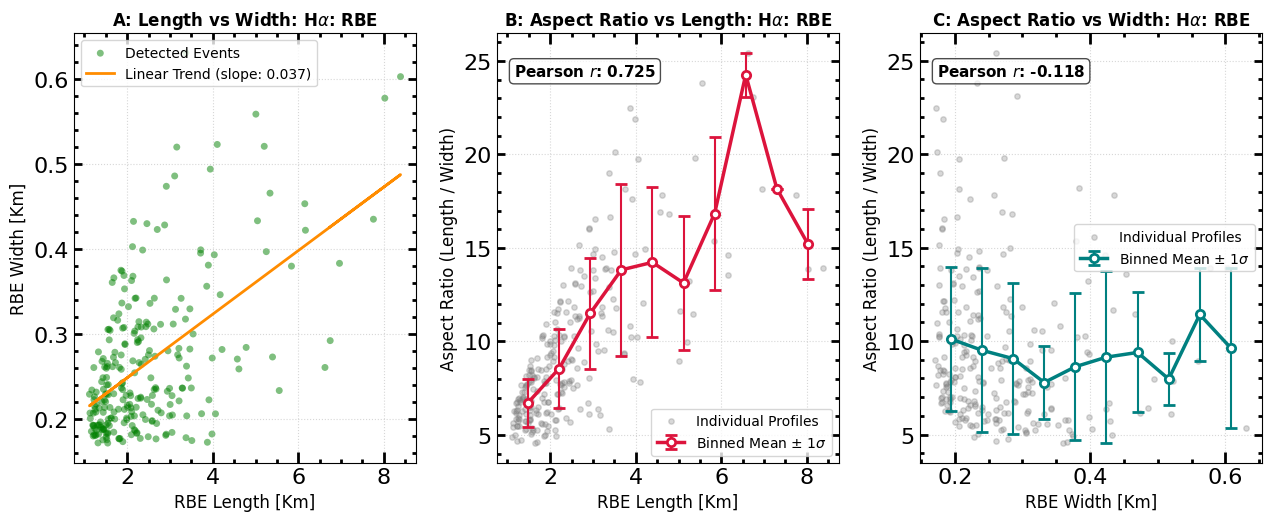

In [2]:

"""
Optimized spicule detection pipeline with line-by-line comments.

Usage:
    - Set `FILENAME` to your FITS file path.
    - Optionally tune parameters in the `Params` dataclass.
    - Call `process_frame(...)` to run detection on a single frame index.
"""

import numpy as np                                     # numeric operations
import matplotlib.pyplot as plt                        # plotting
from astropy.io import fits                            # read FITS files
from scipy.interpolate import interp1d                 # (kept if you need wavelength interpolation)
from skimage import exposure, morphology               # contrast enhancement + morphology
from skimage.filters import frangi, threshold_otsu     # ridge detection + thresholding
from skimage.measure import label, regionprops         # connected component analysis
from skimage.morphology import disk                     # structuring element helper
from scipy.ndimage import gaussian_filter               # optional smoothing
from scipy.integrate import simpson                     # numeric integration for arc length
from scipy.stats import gaussian_kde                    # KDE for distributions
from scipy.signal import find_peaks                     # detect peaks in KDE
import warnings                                         # to suppress runtime warnings
from skimage.morphology import skeletonize
from scipy.ndimage import distance_transform_edt
import numpy as np
import matplotlib.pyplot as plt
from powerlaw import Fit
from scipy.optimize import curve_fit


plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True

# Set minor tick width and length
plt.rcParams['xtick.minor.width'] = 2
plt.rcParams['ytick.minor.width'] = 2
plt.rcParams['xtick.minor.size'] = 3
plt.rcParams['ytick.minor.size'] = 3

# Set minor tick width and length
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['ytick.major.width'] = 2
plt.rcParams['xtick.major.size'] = 8
plt.rcParams['ytick.major.size'] = 6


FILENAME = '/media/ravi/Expansion/30-04-2020/PCDinterpolated_ha_6_206.fits'  
spec_indx=6
FRAME_INDEX=14

WAVELIST = np.array([656.12500,656.15002,656.17499,656.20001,656.22498,
                     656.25000,656.27502,656.29999,656.32501,656.34998,
                     656.37500,656.40002,656.42499,656.45001,656.47498]) 
dt=29.229

# physical/scale conversion
plate_scale = 0.0591                # arcsec/pixel (user-provided)
conversion_factor = plate_scale * 0.725  # Mm/pixel conversion factor (user-provided)

plt.rcParams['font.size']=16

# ---------------------------
# === PROCESSING PARAMETERS
# ---------------------------
class Params:
    """Container with tunable parameters for detection and filtering."""
    # preprocessing
    equalize_clip = 0.012             # clip limit for CLAHE
    equalize_kernel = (60, 60)       # CLAHE kernel (height, width) in pixels
    smooth_sigma = 0.8               # Gaussian smoothing (small) before Frangi

    # frangi / ridge detection
    frangi_sigmas = np.arange(1, 2)  # range of scales to test
    frangi_black_ridges = False      # spicules appear bright on inverted image -> False
    frangi_alpha = 0.2
    frangi_beta = 0.18
    frangi_gamma = 10.0

    # binary postprocessing
    otsu_factor = 0.07                # your threshold_factor

    # region filtering (units: pixels)
    min_length = 30
    max_length = 200
    min_width = 4
    max_width = 15
    min_elongation = 5.0
    curvature_threshold = 0.3
    show_plots = False

P = Params()  

# ---------------------------
# === UTILITY / HELPER FUNCs
# ---------------------------
def load_fits_cube(fname):
    """Load FITS data from `fname` and return numpy array (no header)."""
    # read FITS data; fits.getdata returns a numpy array
    cube = fits.getdata(fname)
    return cube

def normalize_and_invert(image):
    """Normalize image to [0,1], apply CLAHE, and invert (so bright ridges become dark for Frangi when black_ridges=False)."""
    # compute nan mask and operate ignoring NaNs
    nan_mask = np.isnan(image)                              # True where data is NaN
    img = image.copy()                                      # avoid modifying original
    # replace NaNs by min for normalization but keep mask to reassign NaNs later
    finite_mask = ~nan_mask
    if not np.any(finite_mask):
        return img, nan_mask                                # empty frame guard

    img_min = np.nanmin(img)                                # minimum value over finite pixels
    img_max = np.nanmax(img)                                # maximum value
    if img_max == img_min:
        # avoid division by zero for flat images
        norm = np.zeros_like(img, dtype=float)
    else:
        norm = (img - img_min) / (img_max - img_min)        # scale to [0,1]
    # apply CLAHE (adaptive histogram equalization)    
    norm_clahe = exposure.equalize_adapthist(norm, clip_limit=P.equalize_clip, kernel_size=P.equalize_kernel)
    # invert image so bright filaments -> dark (because we set frangi_black_ridges=False below)
    inverted = 1.0 - norm_clahe
    # restore NaNs to mask positions
    inverted[nan_mask] = np.nan
    return inverted, nan_mask

def compute_frangi(inverted_image):
    """Run Frangi vesselness to enhance thin linear structures (spicules)."""
    # replace NaNs by local median for frangi to avoid errors (frangi doesn't accept NaNs)
    nan_mask = np.isnan(inverted_image)
    img = inverted_image.copy()
    if np.any(nan_mask):
        # replace NaNs by a small local smoothing value (median of finite pixels)
        img[nan_mask] = np.nanmedian(img)
    # optional small Gaussian smoothing to stabilize frangi
    img_smooth = gaussian_filter(img, sigma=P.smooth_sigma)
    # run frangi at specified sigmas; faster than using 1..19
    vesselness = frangi(img_smooth,
                        sigmas=P.frangi_sigmas,
                        black_ridges=P.frangi_black_ridges,
                        alpha=P.frangi_alpha,
                        beta=P.frangi_beta,
                        gamma=P.frangi_gamma)
    return vesselness

def binarize_and_clean(vesselness, nan_mask):
    """Threshold vesselness via Otsu*factor, close gaps, remove small objects."""
    # calculate Otsu threshold on finite pixels only
    finite_mask = ~nan_mask
    if not np.any(finite_mask):
        # return empty mask if no finite pixels
        return np.zeros_like(vesselness, dtype=bool)
    base_thresh = threshold_otsu(vesselness[finite_mask])   # Otsu threshold
    thresh = base_thresh * P.otsu_factor                    # scaled threshold
    binary = vesselness > thresh                            # boolean mask
    binary[nan_mask] = False
    return binary


def filter_regions_by_geometry(labeled_img):
    """Filter connected components in `labeled_img` by major/minor/elongation constraints."""
    filtered_mask = np.zeros_like(labeled_img, dtype=bool)   # initialize
    for region in regionprops(labeled_img):
        major = region.major_axis_length
        minor = region.minor_axis_length
        # skip degenerate cases
        if minor == 0:
            continue
        elongation = major / minor
        # apply geometric thresholds
        if P.min_length <= major <= P.max_length and P.min_width <= minor <= P.max_width and elongation >= P.min_elongation:
            filtered_mask[labeled_img == region.label] = True
    return filtered_mask


def fit_spicule_curve(coords):
    """
    Fit a quadratic curve to coordinates, compute arc length and curvature rejection.
    coords: Nx2 array of (row, col) where row=y, col=x
    Returns (length_pixels, width_pixels, x_fit, y_fit) or None if rejected.
    """
    # coordinates as arrays
    y = coords[:, 0].astype(float)   # row index
    x = coords[:, 1].astype(float)   # column index

    # decide whether x = f(y) or y = f(x) (select the direction with larger span)
    span_y = y.max() - y.min()
    span_x = x.max() - x.min()

    try:
        if span_y >= span_x:
            # fit x as a function of y
            coeffs = np.polyfit(y, x, deg=2)                # quadratic fit x(y)
            y_fit = np.linspace(y.min(), y.max(), 200)      # dense sampling along y
            x_fit = np.polyval(coeffs, y_fit)               # fitted x values
            # derivatives of polynomial: first and second derivative (analytic)
            d1 = np.polyval(np.polyder(coeffs), y_fit)     # dx/dy
            d2 = np.polyval(np.polyder(coeffs, 2), y_fit)  # d2x/dy2
            # curvature for parametric curve (x(y), y): κ = |d2x/dy2| / (1 + (dx/dy)^2)^(3/2)
            curvature = np.abs(d2) / (1.0 + d1**2)**1.5
            max_curv = curvature.max()
            if max_curv > P.curvature_threshold:
                return None
            # arc length integral for x(y): ∫ sqrt(1 + (dx/dy)^2) dy
            integrand = np.sqrt(1.0 + d1**2)
            length_pixels = simpson(integrand, y_fit)
            # use minor axis as width candidate (we do not have minor here; caller will set)
            return length_pixels, x_fit, y_fit
        else:
            # fit y as a function of x
            coeffs = np.polyfit(x, y, deg=2)                # quadratic fit y(x)
            x_fit = np.linspace(x.min(), x.max(), 200)      # dense sampling along x
            y_fit = np.polyval(coeffs, x_fit)               # fitted y values
            d1 = np.polyval(np.polyder(coeffs), x_fit)      # dy/dx
            d2 = np.polyval(np.polyder(coeffs, 2), x_fit)   # d2y/dx2
            curvature = np.abs(d2) / (1.0 + d1**2)**1.5
            max_curv = curvature.max()
            if max_curv > P.curvature_threshold:
                return None
            integrand = np.sqrt(1.0 + d1**2)
            length_pixels = simpson(integrand, x_fit)
            return length_pixels, x_fit, y_fit
    except np.linalg.LinAlgError:
        return None

def process_frame(cube, frame_index=FRAME_INDEX):
    """
    Process a single frame from the cube. Returns lists of spicule lengths and widths (in Mm)
    plus an output binary mask for visualization.
    """
    # get the requested 3D frame (matching your cube[kk] indexing)
    data_cube = cube[frame_index]               # e.g. cube[7]
    # select spectral slice index you used previously (data_cube[6] in original)
    spectral_idx = spec_indx
    data = data_cube[spectral_idx]              # 2D image (ny, nx)
    # create NaN mask for later
    nan_mask = np.isnan(data)
    # normalize + enhance + invert (returns image and mask)
    inverted, nan_mask = normalize_and_invert(data)
    # compute vesselness (frangi)
    vessel = compute_frangi(inverted)
    # threshold and clean
    cleaned = binarize_and_clean(vessel, nan_mask)
    # label after cleaning
    labeled = label(cleaned)
    # geometry filtering by major/minor/elongation
    filtered_mask = filter_regions_by_geometry(labeled)
    # final label of filtered objects
    final_labeled = label(filtered_mask)
    regions = regionprops(final_labeled)

    spicule_lengths_px = []                     # store lengths in pixels
    spicule_widths_px = []                      # store widths in pixels (major/minor from regionprops)
    fitted_lines = []                            # store for plotting
    widths_all=[]

    # iterate regions to do curve fit and curvature check
    for region in regions:
        coords = region.coords                    # pixel coordinates of the region
        fit_res = fit_spicule_curve(coords)
        length_px, x_fit00, y_fit00 = fit_res
        y0, x0 = region.centroid
        theta = region.orientation
        a = region.major_axis_length / 2
        b = region.minor_axis_length / 2
    
        t = np.linspace(0, 2*np.pi, 200)
        x_ellipse = x0 + a*np.cos(t)*np.cos(theta) - b*np.sin(t)*np.sin(theta)
        y_ellipse = y0 + a*np.cos(t)*np.sin(theta) + b*np.sin(t)*np.cos(theta)

        # Use curve-based orientation
        dx = x_fit00[-1] - x_fit00[0]
        dy = y_fit00[-1] - y_fit00[0]
        theta = np.arctan2(dy, dx)
        
        # Keep regionprops lengths
        a = region.major_axis_length / 2
        b = region.minor_axis_length / 2
        y0, x0 = region.centroid
        
        t = np.linspace(0, 2*np.pi, 200)
        
        x_ellipse = x0 + a*np.cos(t)*np.cos(theta) - b*np.sin(t)*np.sin(theta)
        y_ellipse = y0 + a*np.cos(t)*np.sin(theta) + b*np.sin(t)*np.cos(theta)
        
        # Minor axis
        dx_m = -np.sin(theta)
        dy_m =  np.cos(theta)
        
        x_minor = np.array([x0 - b*dx_m, x0 + b*dx_m])
        y_minor = np.array([y0 - b*dy_m, y0 + b*dy_m])

        minor = np.sqrt((x_minor[1]-x_minor[0])**2+(y_minor[1]-y_minor[0])**2)
        if minor == 0:
            continue
        # obtain fitted length and curve points
        fit_res = fit_spicule_curve(coords)
        if fit_res is None:
            continue
        # fit_res returns (length_pixels, x_fit, y_fit)
        length_px, x_fit00, y_fit00 = fit_res
        # apply the additional geometry width filter (region.minor_axis_length)
        if not (P.min_width <= minor <= P.max_width):
            continue
        # success: append results
        spicule_lengths_px.append(length_px)
        mask_region = (final_labeled == region.label)
        #length_px, width_px,widths_all_px = measure_spicule_length_width(mask_region)
        spicule_widths_px.append(minor)
        fitted_lines.append((x_fit00, y_fit00))

    # convert to numpy arrays and to Mm units
    lengths_px = np.array(spicule_lengths_px)
    widths_px = np.array(spicule_widths_px)
    lengths_Mm = lengths_px * conversion_factor
    widths_Mm = widths_px * conversion_factor

    if P.show_plots:
        # Top row: original, mask, overlay
        
        plt.subplots(1,3,figsize=(18, 6),sharex=True,sharey=True)
        plt.subplots_adjust(hspace=0.0,wspace=0.0)
        plt.subplot(1, 3, 1)
        plt.imshow(data, cmap='gray', origin='lower',extent=[0,1330*0.0591*0.725,0,1330*0.0591*0.725])
        nan_region=np.isnan(data)
        plt.xlabel('Solar-X [Mm]')
        plt.ylabel('Solar-Y [Mm]')
        plt.text(4, 52, r'H$\alpha$ - 0.75 $\AA$')
        plt.text(2,2,'T ~'+' 08:49 UT')
        plt.text(50,52,'(a)')
        plt.plot([820*0.0591*0.725,820*0.0591*0.725,900*0.0591*0.725,900*0.0591*0.725,820*0.0591*0.725],[540*0.0591*0.725,600*0.0591*0.725,600*0.0591*0.725,540*0.0591*0.725,540*0.0591*0.725],'c')
        #plt.tick_params(axis='x', labelbottom=False)

        #plt.title('Original')

        plt.subplot(1, 3, 2)
        filtered_mask[nan_mask]=np.nan
        plt.imshow(filtered_mask, cmap='gray', origin='lower',extent=[0,1330*0.0591*0.725,0,1330*0.0591*0.725])
        plt.xlabel('Solar-X [Mm]')
        plt.text(4, 52, 'Binary Mask')
        #plt.title('Filtered Mask')
        #plt.tick_params(axis='x', labelbottom=False)
        plt.text(50,52,'(b)')
        plt.plot([820*0.0591*0.725,820*0.0591*0.725,900*0.0591*0.725,900*0.0591*0.725,820*0.0591*0.725],[540*0.0591*0.725,600*0.0591*0.725,600*0.0591*0.725,540*0.0591*0.725,540*0.0591*0.725],'c')
        
        plt.subplot(1, 3, 3)
        plt.imshow(data, cmap='gray', origin='lower',extent=[0,1330*0.0591*0.725,0,1330*0.0591*0.725])
        plt.xlabel('Solar-X [Mm]')
        for (x_fit, y_fit) in fitted_lines:
            # plotting fitted curve (x_fit, y_fit) as red dashed
            plt.plot(x_fit*0.0591*0.725, y_fit*0.0591*0.725, '--r', linewidth=1)
        plt.text(2,52, 'Detected Spicules')
        #plt.axis('off')   
        #plt.tick_params(axis='x', labelbottom=False)
        plt.text(2,2,'N = '+str(len(lengths_Mm)))
        plt.text(50,52,'(c)')
        plt.plot([820*0.0591*0.725,820*0.0591*0.725,900*0.0591*0.725,900*0.0591*0.725,820*0.0591*0.725],[540*0.0591*0.725,600*0.0591*0.725,600*0.0591*0.725,540*0.0591*0.725,540*0.0591*0.725],'c')
        plt.show()

    return lengths_Mm, widths_Mm, filtered_mask,widths_px,lengths_px,regions,widths_all,vessel,fitted_lines


if __name__ == "__main__":
    warnings.filterwarnings("ignore", category=RuntimeWarning)
    cube = load_fits_cube(FILENAME)
    for i in range(177,178):
        lengths, widths, mask ,widths_px,lengths_px,regions,widths_all,vessel,fitted_lines= process_frame(cube, frame_index=i)





import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic

# --- 1. Compute Aspect Ratios and Statistics ---
aspect_ratios = lengths / widths

# Length vs Aspect Ratio stats
bin_means_l, bin_edges_l, _ = binned_statistic(lengths, aspect_ratios, statistic='mean', bins=10)
bin_std_l, _, _ = binned_statistic(lengths, aspect_ratios, statistic='std', bins=10)
bin_centers_l = (bin_edges_l[:-1] + bin_edges_l[1:]) / 2
corr_length = np.corrcoef(lengths, aspect_ratios)[0, 1]

# Width vs Aspect Ratio stats (New)
bin_means_w, bin_edges_w, _ = binned_statistic(widths, aspect_ratios, statistic='mean', bins=10)
bin_std_w, _, _ = binned_statistic(widths, aspect_ratios, statistic='std', bins=10)
bin_centers_w = (bin_edges_w[:-1] + bin_edges_w[1:]) / 2
corr_width = np.corrcoef(widths, aspect_ratios)[0, 1]

print(f"Pearson correlation (Length vs Aspect Ratio): {corr_length:.3f}")
print(f"Pearson correlation (Width vs Aspect Ratio): {corr_width:.3f}")

# --- 2. Plotting Setup ---
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(13, 5.5))

# Plot A: Joint Geometry Distribution (Length vs Width)
ax1.scatter(lengths, widths, color='g', alpha=0.5, edgecolors='none', s=25, label='Detected Events')
m, c = np.polyfit(lengths, widths, 1)
ax1.plot(lengths, m*lengths + c, color='darkorange', linewidth=2, label=f'Linear Trend (slope: {m:.3f})')
ax1.set_xlabel('RBE Length [Km]', fontsize=12)
ax1.set_ylabel('RBE Width [Km]', fontsize=12)
ax1.set_title(r'A: Length vs Width: H$\alpha$: RBE', fontsize=12, fontweight='bold')
ax1.grid(True, linestyle=':', alpha=0.5)
ax1.legend(fontsize=10)

# Plot B: Aspect Ratio vs Length
ax2.scatter(lengths, aspect_ratios, color='#7f7f7f', alpha=0.3, s=15, label='Individual Profiles')
ax2.errorbar(bin_centers_l, bin_means_l, yerr=bin_std_l, fmt='o-', color='crimson', 
             linewidth=2.5, elinewidth=1.5, capsize=4, markerfacecolor='white',
             markeredgecolor='crimson', markeredgewidth=2, label='Binned Mean $\pm$ 1$\sigma$')
ax2.text(0.05, 0.90, f'Pearson $r$: {corr_length:.3f}', transform=ax2.transAxes, 
         fontsize=11, fontweight='bold', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))
ax2.set_xlabel('RBE Length [Km]', fontsize=12)
ax2.set_ylabel('Aspect Ratio (Length / Width)', fontsize=12)
ax2.set_title(r'B: Aspect Ratio vs Length: H$\alpha$: RBE', fontsize=12, fontweight='bold')
ax2.grid(True, linestyle=':', alpha=0.5)
ax2.legend(fontsize=10)

# Plot C: Aspect Ratio vs Width (New)
ax3.scatter(widths, aspect_ratios, color='#7f7f7f', alpha=0.3, s=15, label='Individual Profiles')
ax3.errorbar(bin_centers_w, bin_means_w, yerr=bin_std_w, fmt='o-', color='teal', 
             linewidth=2.5, elinewidth=1.5, capsize=4, markerfacecolor='white',
             markeredgecolor='teal', markeredgewidth=2, label='Binned Mean $\pm$ 1$\sigma$')
ax3.text(0.05, 0.90, f'Pearson $r$: {corr_width:.3f}', transform=ax3.transAxes, 
         fontsize=11, fontweight='bold', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))
ax3.set_xlabel('RBE Width [Km]', fontsize=12)
ax3.set_ylabel('Aspect Ratio (Length / Width)', fontsize=12)
ax3.set_title(r'C: Aspect Ratio vs Width: H$\alpha$: RBE', fontsize=12, fontweight='bold')
ax3.grid(True, linestyle=':', alpha=0.5)
ax3.legend(fontsize=10,loc='center right')
plt.tight_layout()
plt.savefig('/media/ravi/Expansion/30-04-2020/Again_submit_Power_law/Figure_new/LvsW_ha_RBE.png',dpi=400,bbox_inches='tight')
plt.show()


#  Figure 2

177


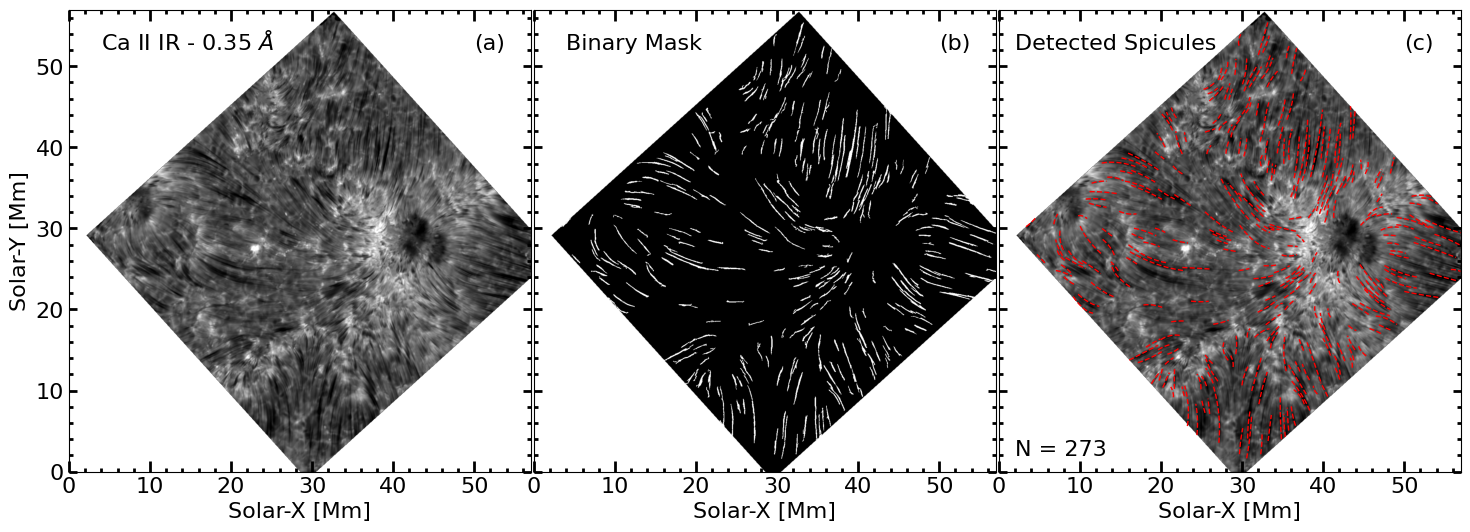

Detected 273 spicules.
Lengths (Mm): mean=2.591, median=2.213
Widths  (Mm): mean=0.259, median=0.231


In [3]:
"""
Optimized spicule detection pipeline with line-by-line comments.

Usage:
    - Set `FILENAME` to your FITS file path.
    - Optionally tune parameters in the `Params` dataclass.
    - Call `process_frame(...)` to run detection on a single frame index.
"""

import numpy as np                                     # numeric operations
import matplotlib.pyplot as plt                        # plotting
from astropy.io import fits                            # read FITS files
from scipy.interpolate import interp1d                 # (kept if you need wavelength interpolation)
from skimage import exposure, morphology               # contrast enhancement + morphology
from skimage.filters import frangi, threshold_otsu     # ridge detection + thresholding
from skimage.measure import label, regionprops         # connected component analysis
from skimage.morphology import disk                     # structuring element helper
from scipy.ndimage import gaussian_filter               # optional smoothing
from scipy.integrate import simpson                     # numeric integration for arc length
from scipy.stats import gaussian_kde                    # KDE for distributions
from scipy.signal import find_peaks                     # detect peaks in KDE
import warnings                                         # to suppress runtime warnings
from skimage.morphology import skeletonize
from scipy.ndimage import distance_transform_edt
import numpy as np
import matplotlib.pyplot as plt
from powerlaw import Fit
from scipy.optimize import curve_fit


plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True

# Set minor tick width and length
plt.rcParams['xtick.minor.width'] = 2
plt.rcParams['ytick.minor.width'] = 2
plt.rcParams['xtick.minor.size'] = 3
plt.rcParams['ytick.minor.size'] = 3

# Set minor tick width and length
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['ytick.major.width'] = 2
plt.rcParams['xtick.major.size'] = 8
plt.rcParams['ytick.major.size'] = 6


FILENAME = '/media/ravi/Expansion/30-04-2020/PCD/interpolated_ca_6_206.fits'  # input FITS cube
                     # top-level cube frame index (same as your loop: for kk in range(7,8))
spec_indx=6

FRAME_INDEX=14
 
dt=29.229

# physical/scale conversion
plate_scale = 0.0591                # arcsec/pixel (user-provided)
conversion_factor = plate_scale * 0.725  # Mm/pixel conversion factor (user-provided)

plt.rcParams['font.size']=16

# ---------------------------
# === PROCESSING PARAMETERS
# ---------------------------
class Params:
    """Container with tunable parameters for detection and filtering."""
    # preprocessing
    equalize_clip = 0.012             # clip limit for CLAHE
    equalize_kernel = (60, 60)       # CLAHE kernel (height, width) in pixels
    smooth_sigma = 0.8               # Gaussian smoothing (small) before Frangi

    # frangi / ridge detection
    frangi_sigmas = np.arange(1, 2)  # range of scales to test
    frangi_black_ridges = False      # spicules appear bright on inverted image -> False
    frangi_alpha = 0.2
    frangi_beta = 0.18
    frangi_gamma = 10.0

    # binary postprocessing
    otsu_factor = 0.12                # your threshold_factor

    # region filtering (units: pixels)
    min_length = 30
    max_length = 500
    min_width = 4
    max_width = 15
    min_elongation = 5.0
    curvature_threshold = 0.3
    show_plots = True

P = Params()  

# ---------------------------
# === UTILITY / HELPER FUNCs
# ---------------------------
def load_fits_cube(fname):
    """Load FITS data from `fname` and return numpy array (no header)."""
    # read FITS data; fits.getdata returns a numpy array
    cube = fits.getdata(fname)
    return cube

def normalize_and_invert(image):
    """Normalize image to [0,1], apply CLAHE, and invert (so bright ridges become dark for Frangi when black_ridges=False)."""
    # compute nan mask and operate ignoring NaNs
    nan_mask = np.isnan(image)                              # True where data is NaN
    img = image.copy()                                      # avoid modifying original
    # replace NaNs by min for normalization but keep mask to reassign NaNs later
    finite_mask = ~nan_mask
    if not np.any(finite_mask):
        return img, nan_mask                                # empty frame guard

    img_min = np.nanmin(img)                                # minimum value over finite pixels
    img_max = np.nanmax(img)                                # maximum value
    if img_max == img_min:
        # avoid division by zero for flat images
        norm = np.zeros_like(img, dtype=float)
    else:
        norm = (img - img_min) / (img_max - img_min)        # scale to [0,1]
    # apply CLAHE (adaptive histogram equalization)    
    norm_clahe = exposure.equalize_adapthist(norm, clip_limit=P.equalize_clip, kernel_size=P.equalize_kernel)
    # invert image so bright filaments -> dark (because we set frangi_black_ridges=False below)
    inverted = 1.0 - norm_clahe
    # restore NaNs to mask positions
    inverted[nan_mask] = np.nan
    return inverted, nan_mask

def compute_frangi(inverted_image):
    """Run Frangi vesselness to enhance thin linear structures (spicules)."""
    # replace NaNs by local median for frangi to avoid errors (frangi doesn't accept NaNs)
    nan_mask = np.isnan(inverted_image)
    img = inverted_image.copy()
    if np.any(nan_mask):
        # replace NaNs by a small local smoothing value (median of finite pixels)
        img[nan_mask] = np.nanmedian(img)
    # optional small Gaussian smoothing to stabilize frangi
    img_smooth = gaussian_filter(img, sigma=P.smooth_sigma)
    # run frangi at specified sigmas; faster than using 1..19
    vesselness = frangi(img_smooth,
                        sigmas=P.frangi_sigmas,
                        black_ridges=P.frangi_black_ridges,
                        alpha=P.frangi_alpha,
                        beta=P.frangi_beta,
                        gamma=P.frangi_gamma)
    return vesselness

def binarize_and_clean(vesselness, nan_mask):
    """Threshold vesselness via Otsu*factor, close gaps, remove small objects."""
    # calculate Otsu threshold on finite pixels only
    finite_mask = ~nan_mask
    if not np.any(finite_mask):
        # return empty mask if no finite pixels
        return np.zeros_like(vesselness, dtype=bool)
    base_thresh = threshold_otsu(vesselness[finite_mask])   # Otsu threshold
    thresh = base_thresh * P.otsu_factor                    # scaled threshold
    binary = vesselness > thresh                            # boolean mask
    binary[nan_mask] = False
    return binary


def filter_regions_by_geometry(labeled_img):
    """Filter connected components in `labeled_img` by major/minor/elongation constraints."""
    filtered_mask = np.zeros_like(labeled_img, dtype=bool)   # initialize
    for region in regionprops(labeled_img):
        major = region.major_axis_length
        minor = region.minor_axis_length
        # skip degenerate cases
        if minor == 0:
            continue
        elongation = major / minor
        # apply geometric thresholds
        if P.min_length <= major <= P.max_length and P.min_width <= minor <= P.max_width and elongation >= P.min_elongation:
            filtered_mask[labeled_img == region.label] = True
    return filtered_mask


def fit_spicule_curve(coords):
    """
    Fit a quadratic curve to coordinates, compute arc length and curvature rejection.
    coords: Nx2 array of (row, col) where row=y, col=x
    Returns (length_pixels, width_pixels, x_fit, y_fit) or None if rejected.
    """
    # coordinates as arrays
    y = coords[:, 0].astype(float)   # row index
    x = coords[:, 1].astype(float)   # column index

    # decide whether x = f(y) or y = f(x) (select the direction with larger span)
    span_y = y.max() - y.min()
    span_x = x.max() - x.min()

    try:
        if span_y >= span_x:
            # fit x as a function of y
            coeffs = np.polyfit(y, x, deg=2)                # quadratic fit x(y)
            y_fit = np.linspace(y.min(), y.max(), 200)      # dense sampling along y
            x_fit = np.polyval(coeffs, y_fit)               # fitted x values
            # derivatives of polynomial: first and second derivative (analytic)
            d1 = np.polyval(np.polyder(coeffs), y_fit)     # dx/dy
            d2 = np.polyval(np.polyder(coeffs, 2), y_fit)  # d2x/dy2
            # curvature for parametric curve (x(y), y): κ = |d2x/dy2| / (1 + (dx/dy)^2)^(3/2)
            curvature = np.abs(d2) / (1.0 + d1**2)**1.5
            max_curv = curvature.max()
            if max_curv > P.curvature_threshold:
                return None
            # arc length integral for x(y): ∫ sqrt(1 + (dx/dy)^2) dy
            integrand = np.sqrt(1.0 + d1**2)
            length_pixels = simpson(integrand, y_fit)
            # use minor axis as width candidate (we do not have minor here; caller will set)
            return length_pixels, x_fit, y_fit
        else:
            # fit y as a function of x
            coeffs = np.polyfit(x, y, deg=2)                # quadratic fit y(x)
            x_fit = np.linspace(x.min(), x.max(), 200)      # dense sampling along x
            y_fit = np.polyval(coeffs, x_fit)               # fitted y values
            d1 = np.polyval(np.polyder(coeffs), x_fit)      # dy/dx
            d2 = np.polyval(np.polyder(coeffs, 2), x_fit)   # d2y/dx2
            curvature = np.abs(d2) / (1.0 + d1**2)**1.5
            max_curv = curvature.max()
            if max_curv > P.curvature_threshold:
                return None
            integrand = np.sqrt(1.0 + d1**2)
            length_pixels = simpson(integrand, x_fit)
            return length_pixels, x_fit, y_fit
    except np.linalg.LinAlgError:
        return None

def process_frame(cube, frame_index=FRAME_INDEX):
    """
    Process a single frame from the cube. Returns lists of spicule lengths and widths (in Mm)
    plus an output binary mask for visualization.
    """
    # get the requested 3D frame (matching your cube[kk] indexing)
    data_cube = cube[frame_index]               # e.g. cube[7]
    # select spectral slice index you used previously (data_cube[6] in original)
    spectral_idx = spec_indx
    data = data_cube[spectral_idx]              # 2D image (ny, nx)
    # create NaN mask for later
    nan_mask = np.isnan(data)
    # normalize + enhance + invert (returns image and mask)
    inverted, nan_mask = normalize_and_invert(data)
    # compute vesselness (frangi)
    vessel = compute_frangi(inverted)
    # threshold and clean
    cleaned = binarize_and_clean(vessel, nan_mask)
    # label after cleaning
    labeled = label(cleaned)
    # geometry filtering by major/minor/elongation
    filtered_mask = filter_regions_by_geometry(labeled)
    # final label of filtered objects
    final_labeled = label(filtered_mask)
    regions = regionprops(final_labeled)

    spicule_lengths_px = []                     # store lengths in pixels
    spicule_widths_px = []                      # store widths in pixels (major/minor from regionprops)
    fitted_lines = []                            # store for plotting
    widths_all=[]

    # iterate regions to do curve fit and curvature check
    for region in regions:
        coords = region.coords                    # pixel coordinates of the region
        fit_res = fit_spicule_curve(coords)
        length_px, x_fit00, y_fit00 = fit_res
        y0, x0 = region.centroid
        theta = region.orientation
        a = region.major_axis_length / 2
        b = region.minor_axis_length / 2
    
        t = np.linspace(0, 2*np.pi, 200)
        x_ellipse = x0 + a*np.cos(t)*np.cos(theta) - b*np.sin(t)*np.sin(theta)
        y_ellipse = y0 + a*np.cos(t)*np.sin(theta) + b*np.sin(t)*np.cos(theta)

        # Use curve-based orientation
        dx = x_fit00[-1] - x_fit00[0]
        dy = y_fit00[-1] - y_fit00[0]
        theta = np.arctan2(dy, dx)
        
        # Keep regionprops lengths
        a = region.major_axis_length / 2
        b = region.minor_axis_length / 2
        y0, x0 = region.centroid
        
        t = np.linspace(0, 2*np.pi, 200)
        
        x_ellipse = x0 + a*np.cos(t)*np.cos(theta) - b*np.sin(t)*np.sin(theta)
        y_ellipse = y0 + a*np.cos(t)*np.sin(theta) + b*np.sin(t)*np.cos(theta)
        
        # Minor axis
        dx_m = -np.sin(theta)
        dy_m =  np.cos(theta)
        
        x_minor = np.array([x0 - b*dx_m, x0 + b*dx_m])
        y_minor = np.array([y0 - b*dy_m, y0 + b*dy_m])

        minor = np.sqrt((x_minor[1]-x_minor[0])**2+(y_minor[1]-y_minor[0])**2)
        if minor == 0:
            continue
        # obtain fitted length and curve points
        fit_res = fit_spicule_curve(coords)
        if fit_res is None:
            continue
        # fit_res returns (length_pixels, x_fit, y_fit)
        length_px, x_fit00, y_fit00 = fit_res
        # apply the additional geometry width filter (region.minor_axis_length)
        if not (P.min_width <= minor <= P.max_width):
            continue
        # success: append results
        spicule_lengths_px.append(length_px)
        mask_region = (final_labeled == region.label)
        #length_px, width_px,widths_all_px = measure_spicule_length_width(mask_region)
        spicule_widths_px.append(minor)
        fitted_lines.append((x_fit00, y_fit00))

    # convert to numpy arrays and to Mm units
    lengths_px = np.array(spicule_lengths_px)
    widths_px = np.array(spicule_widths_px)
    lengths_Mm = lengths_px * conversion_factor
    widths_Mm = widths_px * conversion_factor

    if P.show_plots:
        # Top row: original, mask, overlay
        plt.subplots(1,3,figsize=(18, 6),sharex=True,sharey=True)
        plt.subplots_adjust(hspace=0.0,wspace=0.0)
        plt.subplot(1, 3, 1)
        plt.imshow(data, cmap='gray', origin='lower',extent=[0,1330*0.0591*0.725,0,1330*0.0591*0.725],vmax=np.nanmean(data)*1.8,vmin=np.nanmean(data)*0.6)
        nan_region=np.isnan(data)
        plt.xlabel('Solar-X [Mm]')
        plt.ylabel('Solar-Y [Mm]')
        plt.text(50,52,'(a)')
        plt.text(4, 52, r'Ca II IR - 0.35 $\AA$')
        #plt.tick_params(axis='x', labelbottom=False)


        plt.subplot(1, 3, 2)
        filtered_mask[nan_mask]=np.nan
        plt.imshow(filtered_mask, cmap='gray', origin='lower',extent=[0,1330*0.0591*0.725,0,1330*0.0591*0.725])
        plt.xlabel('Solar-X [Mm]')
        plt.text(4, 52, 'Binary Mask')
        #plt.title('Filtered Mask')
        #plt.tick_params(axis='x', labelbottom=False)
        plt.text(50,52,'(b)')
        
        plt.subplot(1, 3, 3)
        plt.imshow(data, cmap='gray', origin='lower',extent=[0,1330*0.0591*0.725,0,1330*0.0591*0.725],vmax=np.nanmean(data)*1.8,vmin=np.nanmean(data)*0.6)
        plt.xlabel('Solar-X [Mm]')
        for (x_fit, y_fit) in fitted_lines:
            # plotting fitted curve (x_fit, y_fit) as red dashed
            plt.plot(x_fit*0.0591*0.725, y_fit*0.0591*0.725, '--r', linewidth=1)
        plt.text(2,52, 'Detected Spicules')
        #plt.axis('off')   
        #plt.tick_params(axis='x', labelbottom=False)
        plt.text(2,2,'N = '+str(len(lengths_Mm)))
        plt.text(50,52,'(c)')
        plt.savefig('/media/ravi/Expansion/30-04-2020/Again_submit_Power_law/figures/CaII_Wing_Spicule_detection.png',dpi=300,bbox_inches='tight')
        plt.show()

    return lengths_Mm, widths_Mm, filtered_mask,widths_px,lengths_px,regions,widths_all,vessel,fitted_lines


if __name__ == "__main__":
    warnings.filterwarnings("ignore", category=RuntimeWarning)
    cube = load_fits_cube(FILENAME)
    for i in range(177,178):
        print(i)
        lengths, widths, mask ,widths_px,lengths_px,regions,widths_all,vessel,fitted_lines= process_frame(cube, frame_index=i)
        print(f"Detected {len(lengths)} spicules.")
        if len(lengths) > 0:
            print(f"Lengths (Mm): mean={np.mean(lengths):.3f}, median={np.median(lengths):.3f}")
            print(f"Widths  (Mm): mean={np.mean(widths):.3f}, median={np.median(widths):.3f}")

# Figure 6

177


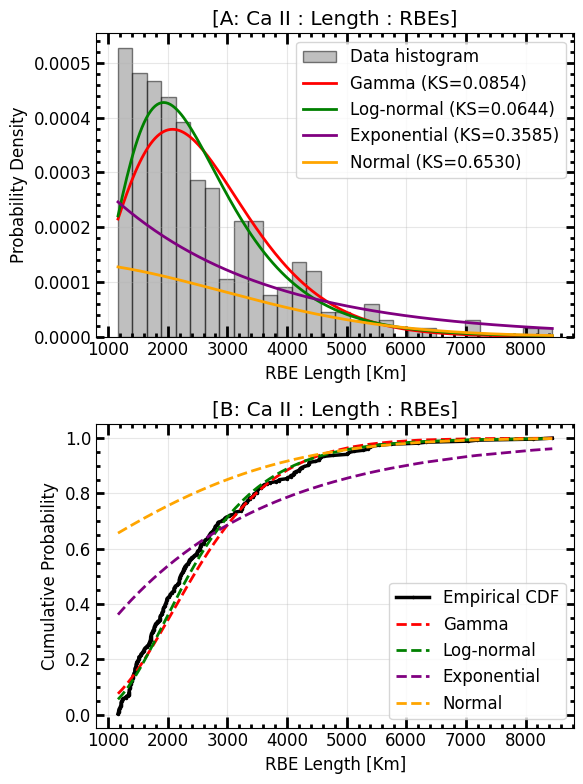


Log-Normal Fit Results : RBE Length [Km]
mu      = 7.7579
sigma   = 0.4386
KS      = 0.0644



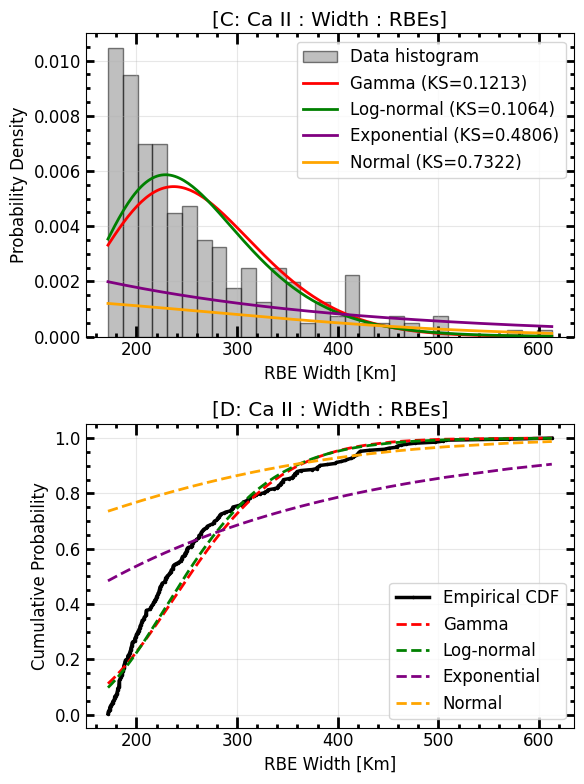


Log-Normal Fit Results : RBE Width [Km]
mu      = 5.5145
sigma   = 0.2854
KS      = 0.1064



In [4]:
"""
Optimized spicule detection pipeline with line-by-line comments.

Usage:
    - Set `FILENAME` to your FITS file path.
    - Optionally tune parameters in the `Params` dataclass.
    - Call `process_frame(...)` to run detection on a single frame index.
"""

import numpy as np                                     # numeric operations
import matplotlib.pyplot as plt                        # plotting
from astropy.io import fits                            # read FITS files
from scipy.interpolate import interp1d                 # (kept if you need wavelength interpolation)
from skimage import exposure, morphology               # contrast enhancement + morphology
from skimage.filters import frangi, threshold_otsu     # ridge detection + thresholding
from skimage.measure import label, regionprops         # connected component analysis
from skimage.morphology import disk                     # structuring element helper
from scipy.ndimage import gaussian_filter               # optional smoothing
from scipy.integrate import simpson                     # numeric integration for arc length
from scipy.stats import gaussian_kde                    # KDE for distributions
from scipy.signal import find_peaks                     # detect peaks in KDE
import warnings                                         # to suppress runtime warnings
from skimage.morphology import skeletonize
from scipy.ndimage import distance_transform_edt
import numpy as np
import matplotlib.pyplot as plt
from powerlaw import Fit
from scipy.optimize import curve_fit


plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True

# Set minor tick width and length
plt.rcParams['xtick.minor.width'] = 2
plt.rcParams['ytick.minor.width'] = 2
plt.rcParams['xtick.minor.size'] = 3
plt.rcParams['ytick.minor.size'] = 3

# Set minor tick width and length
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['ytick.major.width'] = 2
plt.rcParams['xtick.major.size'] = 8
plt.rcParams['ytick.major.size'] = 6


FILENAME = '/media/ravi/Expansion/30-04-2020/PCD/interpolated_ca_6_206.fits'  # input FITS cube
                     # top-level cube frame index (same as your loop: for kk in range(7,8))
spec_indx=6

FRAME_INDEX=14
 
dt=29.229

# physical/scale conversion
plate_scale = 0.0591                # arcsec/pixel (user-provided)
conversion_factor = plate_scale * 0.725  # Mm/pixel conversion factor (user-provided)

plt.rcParams['font.size']=16

# ---------------------------
# === PROCESSING PARAMETERS
# ---------------------------
class Params:
    """Container with tunable parameters for detection and filtering."""
    # preprocessing
    equalize_clip = 0.012             # clip limit for CLAHE
    equalize_kernel = (60, 60)       # CLAHE kernel (height, width) in pixels
    smooth_sigma = 0.8               # Gaussian smoothing (small) before Frangi

    # frangi / ridge detection
    frangi_sigmas = np.arange(1, 2)  # range of scales to test
    frangi_black_ridges = False      # spicules appear bright on inverted image -> False
    frangi_alpha = 0.2
    frangi_beta = 0.18
    frangi_gamma = 10.0

    # binary postprocessing
    otsu_factor = 0.12                # your threshold_factor

    # region filtering (units: pixels)
    min_length = 30
    max_length = 500
    min_width = 4
    max_width = 15
    min_elongation = 5.0
    curvature_threshold = 0.3
    show_plots = False

P = Params()  

# ---------------------------
# === UTILITY / HELPER FUNCs
# ---------------------------
def load_fits_cube(fname):
    """Load FITS data from `fname` and return numpy array (no header)."""
    # read FITS data; fits.getdata returns a numpy array
    cube = fits.getdata(fname)
    return cube

def normalize_and_invert(image):
    """Normalize image to [0,1], apply CLAHE, and invert (so bright ridges become dark for Frangi when black_ridges=False)."""
    # compute nan mask and operate ignoring NaNs
    nan_mask = np.isnan(image)                              # True where data is NaN
    img = image.copy()                                      # avoid modifying original
    # replace NaNs by min for normalization but keep mask to reassign NaNs later
    finite_mask = ~nan_mask
    if not np.any(finite_mask):
        return img, nan_mask                                # empty frame guard

    img_min = np.nanmin(img)                                # minimum value over finite pixels
    img_max = np.nanmax(img)                                # maximum value
    if img_max == img_min:
        # avoid division by zero for flat images
        norm = np.zeros_like(img, dtype=float)
    else:
        norm = (img - img_min) / (img_max - img_min)        # scale to [0,1]
    # apply CLAHE (adaptive histogram equalization)    
    norm_clahe = exposure.equalize_adapthist(norm, clip_limit=P.equalize_clip, kernel_size=P.equalize_kernel)
    # invert image so bright filaments -> dark (because we set frangi_black_ridges=False below)
    inverted = 1.0 - norm_clahe
    # restore NaNs to mask positions
    inverted[nan_mask] = np.nan
    return inverted, nan_mask

def compute_frangi(inverted_image):
    """Run Frangi vesselness to enhance thin linear structures (spicules)."""
    # replace NaNs by local median for frangi to avoid errors (frangi doesn't accept NaNs)
    nan_mask = np.isnan(inverted_image)
    img = inverted_image.copy()
    if np.any(nan_mask):
        # replace NaNs by a small local smoothing value (median of finite pixels)
        img[nan_mask] = np.nanmedian(img)
    # optional small Gaussian smoothing to stabilize frangi
    img_smooth = gaussian_filter(img, sigma=P.smooth_sigma)
    # run frangi at specified sigmas; faster than using 1..19
    vesselness = frangi(img_smooth,
                        sigmas=P.frangi_sigmas,
                        black_ridges=P.frangi_black_ridges,
                        alpha=P.frangi_alpha,
                        beta=P.frangi_beta,
                        gamma=P.frangi_gamma)
    return vesselness

def binarize_and_clean(vesselness, nan_mask):
    """Threshold vesselness via Otsu*factor, close gaps, remove small objects."""
    # calculate Otsu threshold on finite pixels only
    finite_mask = ~nan_mask
    if not np.any(finite_mask):
        # return empty mask if no finite pixels
        return np.zeros_like(vesselness, dtype=bool)
    base_thresh = threshold_otsu(vesselness[finite_mask])   # Otsu threshold
    thresh = base_thresh * P.otsu_factor                    # scaled threshold
    binary = vesselness > thresh                            # boolean mask
    binary[nan_mask] = False
    return binary


def filter_regions_by_geometry(labeled_img):
    """Filter connected components in `labeled_img` by major/minor/elongation constraints."""
    filtered_mask = np.zeros_like(labeled_img, dtype=bool)   # initialize
    for region in regionprops(labeled_img):
        major = region.major_axis_length
        minor = region.minor_axis_length
        # skip degenerate cases
        if minor == 0:
            continue
        elongation = major / minor
        # apply geometric thresholds
        if P.min_length <= major <= P.max_length and P.min_width <= minor <= P.max_width and elongation >= P.min_elongation:
            filtered_mask[labeled_img == region.label] = True
    return filtered_mask


def fit_spicule_curve(coords):
    """
    Fit a quadratic curve to coordinates, compute arc length and curvature rejection.
    coords: Nx2 array of (row, col) where row=y, col=x
    Returns (length_pixels, width_pixels, x_fit, y_fit) or None if rejected.
    """
    # coordinates as arrays
    y = coords[:, 0].astype(float)   # row index
    x = coords[:, 1].astype(float)   # column index

    # decide whether x = f(y) or y = f(x) (select the direction with larger span)
    span_y = y.max() - y.min()
    span_x = x.max() - x.min()

    try:
        if span_y >= span_x:
            # fit x as a function of y
            coeffs = np.polyfit(y, x, deg=2)                # quadratic fit x(y)
            y_fit = np.linspace(y.min(), y.max(), 200)      # dense sampling along y
            x_fit = np.polyval(coeffs, y_fit)               # fitted x values
            # derivatives of polynomial: first and second derivative (analytic)
            d1 = np.polyval(np.polyder(coeffs), y_fit)     # dx/dy
            d2 = np.polyval(np.polyder(coeffs, 2), y_fit)  # d2x/dy2
            # curvature for parametric curve (x(y), y): κ = |d2x/dy2| / (1 + (dx/dy)^2)^(3/2)
            curvature = np.abs(d2) / (1.0 + d1**2)**1.5
            max_curv = curvature.max()
            if max_curv > P.curvature_threshold:
                return None
            # arc length integral for x(y): ∫ sqrt(1 + (dx/dy)^2) dy
            integrand = np.sqrt(1.0 + d1**2)
            length_pixels = simpson(integrand, y_fit)
            # use minor axis as width candidate (we do not have minor here; caller will set)
            return length_pixels, x_fit, y_fit
        else:
            # fit y as a function of x
            coeffs = np.polyfit(x, y, deg=2)                # quadratic fit y(x)
            x_fit = np.linspace(x.min(), x.max(), 200)      # dense sampling along x
            y_fit = np.polyval(coeffs, x_fit)               # fitted y values
            d1 = np.polyval(np.polyder(coeffs), x_fit)      # dy/dx
            d2 = np.polyval(np.polyder(coeffs, 2), x_fit)   # d2y/dx2
            curvature = np.abs(d2) / (1.0 + d1**2)**1.5
            max_curv = curvature.max()
            if max_curv > P.curvature_threshold:
                return None
            integrand = np.sqrt(1.0 + d1**2)
            length_pixels = simpson(integrand, x_fit)
            return length_pixels, x_fit, y_fit
    except np.linalg.LinAlgError:
        return None

def process_frame(cube, frame_index=FRAME_INDEX):
    """
    Process a single frame from the cube. Returns lists of spicule lengths and widths (in Mm)
    plus an output binary mask for visualization.
    """
    # get the requested 3D frame (matching your cube[kk] indexing)
    data_cube = cube[frame_index]               # e.g. cube[7]
    # select spectral slice index you used previously (data_cube[6] in original)
    spectral_idx = spec_indx
    data = data_cube[spectral_idx]              # 2D image (ny, nx)
    # create NaN mask for later
    nan_mask = np.isnan(data)
    # normalize + enhance + invert (returns image and mask)
    inverted, nan_mask = normalize_and_invert(data)
    # compute vesselness (frangi)
    vessel = compute_frangi(inverted)
    # threshold and clean
    cleaned = binarize_and_clean(vessel, nan_mask)
    # label after cleaning
    labeled = label(cleaned)
    # geometry filtering by major/minor/elongation
    filtered_mask = filter_regions_by_geometry(labeled)
    # final label of filtered objects
    final_labeled = label(filtered_mask)
    regions = regionprops(final_labeled)

    spicule_lengths_px = []                     # store lengths in pixels
    spicule_widths_px = []                      # store widths in pixels (major/minor from regionprops)
    fitted_lines = []                            # store for plotting
    widths_all=[]

    # iterate regions to do curve fit and curvature check
    for region in regions:
        coords = region.coords                    # pixel coordinates of the region
        fit_res = fit_spicule_curve(coords)
        length_px, x_fit00, y_fit00 = fit_res
        y0, x0 = region.centroid
        theta = region.orientation
        a = region.major_axis_length / 2
        b = region.minor_axis_length / 2
    
        t = np.linspace(0, 2*np.pi, 200)
        x_ellipse = x0 + a*np.cos(t)*np.cos(theta) - b*np.sin(t)*np.sin(theta)
        y_ellipse = y0 + a*np.cos(t)*np.sin(theta) + b*np.sin(t)*np.cos(theta)

        # Use curve-based orientation
        dx = x_fit00[-1] - x_fit00[0]
        dy = y_fit00[-1] - y_fit00[0]
        theta = np.arctan2(dy, dx)
        
        # Keep regionprops lengths
        a = region.major_axis_length / 2
        b = region.minor_axis_length / 2
        y0, x0 = region.centroid
        
        t = np.linspace(0, 2*np.pi, 200)
        
        x_ellipse = x0 + a*np.cos(t)*np.cos(theta) - b*np.sin(t)*np.sin(theta)
        y_ellipse = y0 + a*np.cos(t)*np.sin(theta) + b*np.sin(t)*np.cos(theta)
        
        # Minor axis
        dx_m = -np.sin(theta)
        dy_m =  np.cos(theta)
        
        x_minor = np.array([x0 - b*dx_m, x0 + b*dx_m])
        y_minor = np.array([y0 - b*dy_m, y0 + b*dy_m])

        minor = np.sqrt((x_minor[1]-x_minor[0])**2+(y_minor[1]-y_minor[0])**2)
        if minor == 0:
            continue
        # obtain fitted length and curve points
        fit_res = fit_spicule_curve(coords)
        if fit_res is None:
            continue
        # fit_res returns (length_pixels, x_fit, y_fit)
        length_px, x_fit00, y_fit00 = fit_res
        # apply the additional geometry width filter (region.minor_axis_length)
        if not (P.min_width <= minor <= P.max_width):
            continue
        # success: append results
        spicule_lengths_px.append(length_px)
        mask_region = (final_labeled == region.label)
        #length_px, width_px,widths_all_px = measure_spicule_length_width(mask_region)
        spicule_widths_px.append(minor)
        fitted_lines.append((x_fit00, y_fit00))

    # convert to numpy arrays and to Mm units
    lengths_px = np.array(spicule_lengths_px)
    widths_px = np.array(spicule_widths_px)
    lengths_Mm = lengths_px * conversion_factor
    widths_Mm = widths_px * conversion_factor

    if P.show_plots:
        # Top row: original, mask, overlay
        plt.subplots(1,3,figsize=(18, 6),sharex=True,sharey=True)
        plt.subplots_adjust(hspace=0.0,wspace=0.0)
        plt.subplot(1, 3, 1)
        plt.imshow(data, cmap='gray', origin='lower',extent=[0,1330*0.0591*0.725,0,1330*0.0591*0.725],vmax=np.nanmean(data)*1.8,vmin=np.nanmean(data)*0.6)
        nan_region=np.isnan(data)
        plt.xlabel('Solar-X [Mm]')
        plt.ylabel('Solar-Y [Mm]')
        plt.text(50,52,'(a)')
        plt.text(4, 52, r'Ca II IR - 0.35 $\AA$')
        #plt.tick_params(axis='x', labelbottom=False)


        plt.subplot(1, 3, 2)
        filtered_mask[nan_mask]=np.nan
        plt.imshow(filtered_mask, cmap='gray', origin='lower',extent=[0,1330*0.0591*0.725,0,1330*0.0591*0.725])
        plt.xlabel('Solar-X [Mm]')
        plt.text(4, 52, 'Binary Mask')
        #plt.title('Filtered Mask')
        #plt.tick_params(axis='x', labelbottom=False)
        plt.text(50,52,'(b)')
        
        plt.subplot(1, 3, 3)
        plt.imshow(data, cmap='gray', origin='lower',extent=[0,1330*0.0591*0.725,0,1330*0.0591*0.725],vmax=np.nanmean(data)*1.8,vmin=np.nanmean(data)*0.6)
        plt.xlabel('Solar-X [Mm]')
        for (x_fit, y_fit) in fitted_lines:
            # plotting fitted curve (x_fit, y_fit) as red dashed
            plt.plot(x_fit*0.0591*0.725, y_fit*0.0591*0.725, '--r', linewidth=1)
        plt.text(2,52, 'Detected Spicules')
        #plt.axis('off')   
        #plt.tick_params(axis='x', labelbottom=False)
        plt.text(2,2,'N = '+str(len(lengths_Mm)))
        plt.text(50,52,'(c)')
        plt.savefig('/media/ravi/Expansion/30-04-2020/Again_submit_Power_law/figures/CaII_Wing_Spicule_detection.png',dpi=300,bbox_inches='tight')
        plt.show()

    return lengths_Mm, widths_Mm, filtered_mask,widths_px,lengths_px,regions,widths_all,vessel,fitted_lines


if __name__ == "__main__":
    warnings.filterwarnings("ignore", category=RuntimeWarning)
    cube = load_fits_cube(FILENAME)
    for i in range(177,178):
        print(i)
        lengths, widths, mask ,widths_px,lengths_px,regions,widths_all,vessel,fitted_lines= process_frame(cube, frame_index=i)




import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams['font.size']=12

def fit_all_distributions(data,xlabel='Value'):
    """
    Fit multiple distributions to 1D array and overplot them
    Returns KS statistics for all distributions
    """
    sorted_data = np.sort(data)
    empirical_cdf = np.arange(1, len(data)+1) / len(data)
    
    # Define distributions to fit
    distributions = {
        'Gamma': stats.gamma,
        'Log-normal': stats.lognorm,
        'Exponential': stats.expon,
        'Normal': stats.norm}
    
    # Store results
    results = {}
    colors = ['red', 'green', 'purple', 'orange']
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 8))
    
    # Left plot: PDF (probability density function)
    ax1.hist(data, bins=30, density=True, alpha=0.5, color='gray', 
             label='Data histogram', edgecolor='black')
    
    x_range = np.linspace(min(data), max(data), 200)
    
    # Right plot: CDF (cumulative distribution function)
    ax2.plot(sorted_data, empirical_cdf, 'k-', linewidth=2.5, 
             label='Empirical CDF', marker='.', markersize=3)
    
    # Fit each distribution
    for (name, dist), color in zip(distributions.items(), colors):
        try:
            # Fit distribution (floc=0 for Gamma, Exponential, Weibull to avoid negative)
            if name in ['Gamma', 'Exponential']:
                params = dist.fit(data, floc=0)
            else:
                params = dist.fit(data, floc=0)
            
            # Calculate PDF
            pdf_fitted = dist.pdf(x_range, *params)
            
            # Calculate CDF
            theoretical_cdf = dist.cdf(sorted_data, *params)
            
            # Calculate KS statistic
            ks_stat = np.max(np.abs(empirical_cdf - theoretical_cdf))
            
            # Store results
            results[name] = {
                'ks': ks_stat,
                'params': params,
                'color': color
            }
            
            # Plot PDF with KS value in label
            ax1.plot(x_range, pdf_fitted, color=color, linewidth=2, 
                    label=f'{name} (KS={ks_stat:.4f})')
            
            # Plot CDF with KS value in label
            ax2.plot(sorted_data, theoretical_cdf, color=color, 
                    linestyle='--', linewidth=2, label=f'{name}')
            
        except Exception as e:
            print(f"Could not fit {name}: {e}")
    
    # Customize plots
    ax1.set_xlabel(xlabel)
    ax1.set_ylabel('Probability Density')
    ax1.set_title(r'[A: Ca II : Length : RBEs]')
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.3)
    
    ax2.set_xlabel(xlabel)
    ax2.set_ylabel('Cumulative Probability')
    ax2.set_title(r'[B: Ca II : Length : RBEs]')
    ax2.legend(loc='lower right')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('/media/ravi/Expansion/30-04-2020/Again_submit_Power_law/Figure_new/Distribution_Lengths_RBEs_Ca.png',bbox_inches='tight',dpi=500)
    plt.show()
    
    lognorm_params = results['Log-normal']['params']
    ks_lognorm = results['Log-normal']['ks']

    sigma = lognorm_params[0]
    loc    = lognorm_params[1]
    scale  = lognorm_params[2]
    
    mu = np.log(scale)
    
    print('\n' + '='*50)
    print(f'Log-Normal Fit Results : {xlabel}')
    print('='*50)
    print(f'mu      = {mu:.4f}')
    print(f'sigma   = {sigma:.4f}')
    print(f'KS      = {ks_lognorm:.4f}')
    print('='*50 + '\n')
    
    return results,params,lognorm_params,loc

# Example usage with sample data
if __name__ == "__main__":
   lengths=np.array(lengths)*1000
   results,params,lognorm_params,loc = fit_all_distributions(lengths,xlabel='RBE Length [Km]')



import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def fit_all_distributions(data,xlabel='Value'):
    """
    Fit multiple distributions to 1D array and overplot them
    Returns KS statistics for all distributions
    """
    sorted_data = np.sort(data)
    empirical_cdf = np.arange(1, len(data)+1) / len(data)
    
    # Define distributions to fit
    distributions = {
        'Gamma': stats.gamma,
        'Log-normal': stats.lognorm,
        'Exponential': stats.expon,
        'Normal': stats.norm}
    
    # Store results
    results = {}
    colors = ['red', 'green', 'purple', 'orange']
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6,8))
    
    # Left plot: PDF (probability density function)
    ax1.hist(data, bins=30, density=True, alpha=0.5, color='gray', 
             label='Data histogram', edgecolor='black')
    
    x_range = np.linspace(min(data), max(data), 200)
    
    # Right plot: CDF (cumulative distribution function)
    ax2.plot(sorted_data, empirical_cdf, 'k-', linewidth=2.5, 
             label='Empirical CDF', marker='.', markersize=3)
    
    # Fit each distribution
    for (name, dist), color in zip(distributions.items(), colors):
        try:
            # Fit distribution (floc=0 for Gamma, Exponential, Weibull to avoid negative)
            if name in ['Gamma', 'Exponential']:
                params = dist.fit(data, floc=0)
            else:
                params = dist.fit(data, floc=0)
            
            # Calculate PDF
            pdf_fitted = dist.pdf(x_range, *params)
            
            # Calculate CDF
            theoretical_cdf = dist.cdf(sorted_data, *params)
            
            # Calculate KS statistic
            ks_stat = np.max(np.abs(empirical_cdf - theoretical_cdf))
            
            # Store results
            results[name] = {
                'ks': ks_stat,
                'params': params,
                'color': color
            }
            
            # Plot PDF with KS value in label
            ax1.plot(x_range, pdf_fitted, color=color, linewidth=2, 
                    label=f'{name} (KS={ks_stat:.4f})')
            
            # Plot CDF with KS value in label
            ax2.plot(sorted_data, theoretical_cdf, color=color, 
                    linestyle='--', linewidth=2, label=f'{name}')
            
        except Exception as e:
            print(f"Could not fit {name}: {e}")
    
    # Customize plots
    ax1.set_xlabel(xlabel)
    ax1.set_ylabel('Probability Density')
    ax1.set_title(r'[C: Ca II : Width : RBEs]')
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.3)
    
    ax2.set_xlabel(xlabel)
    ax2.set_ylabel('Cumulative Probability')
    ax2.set_title(r'[D: Ca II : Width : RBEs]')
    ax2.legend(loc='lower right')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('/media/ravi/Expansion/30-04-2020/Again_submit_Power_law/Figure_new/Distribution_Width_RBEs_Ca.png',bbox_inches='tight',dpi=500)
    plt.show()
    
    lognorm_params = results['Log-normal']['params']
    ks_lognorm = results['Log-normal']['ks']

    sigma = lognorm_params[0]
    loc    = lognorm_params[1]
    scale  = lognorm_params[2]
    
    mu = np.log(scale)
    
    print('\n' + '='*50)
    print(f'Log-Normal Fit Results : {xlabel}')
    print('='*50)
    print(f'mu      = {mu:.4f}')
    print(f'sigma   = {sigma:.4f}')
    print(f'KS      = {ks_lognorm:.4f}')
    print('='*50 + '\n')
    
    return results,params,lognorm_params,loc

# Example usage with sample data
if __name__ == "__main__":
   widths=np.array(widths)*1000
   results,params,lognorm_params,loc = fit_all_distributions(widths,xlabel='RBE Width [Km]')



# Figure 4

177
Detected 273 spicules.
Lengths (Mm): mean=2.591, median=2.213
Widths  (Mm): mean=0.259, median=0.231
Pearson correlation (Length vs Aspect Ratio): 0.757
Pearson correlation (Width vs Aspect Ratio): -0.195


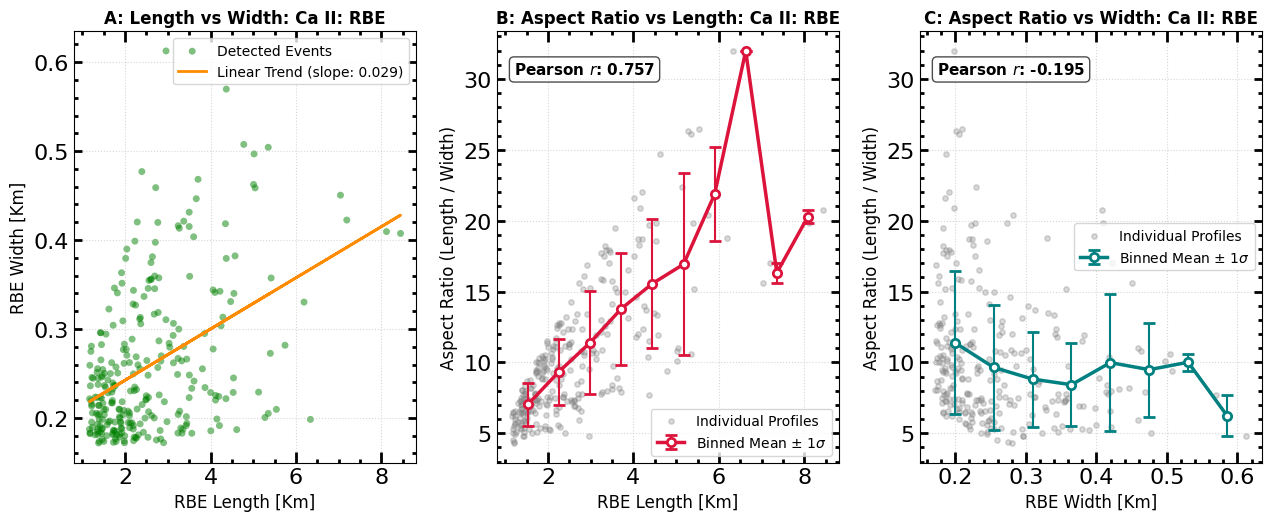

In [5]:
"""
Optimized spicule detection pipeline with line-by-line comments.

Usage:
    - Set `FILENAME` to your FITS file path.
    - Optionally tune parameters in the `Params` dataclass.
    - Call `process_frame(...)` to run detection on a single frame index.
"""

import numpy as np                                     # numeric operations
import matplotlib.pyplot as plt                        # plotting
from astropy.io import fits                            # read FITS files
from scipy.interpolate import interp1d                 # (kept if you need wavelength interpolation)
from skimage import exposure, morphology               # contrast enhancement + morphology
from skimage.filters import frangi, threshold_otsu     # ridge detection + thresholding
from skimage.measure import label, regionprops         # connected component analysis
from skimage.morphology import disk                     # structuring element helper
from scipy.ndimage import gaussian_filter               # optional smoothing
from scipy.integrate import simpson                     # numeric integration for arc length
from scipy.stats import gaussian_kde                    # KDE for distributions
from scipy.signal import find_peaks                     # detect peaks in KDE
import warnings                                         # to suppress runtime warnings
from skimage.morphology import skeletonize
from scipy.ndimage import distance_transform_edt
import numpy as np
import matplotlib.pyplot as plt
from powerlaw import Fit
from scipy.optimize import curve_fit


plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True

# Set minor tick width and length
plt.rcParams['xtick.minor.width'] = 2
plt.rcParams['ytick.minor.width'] = 2
plt.rcParams['xtick.minor.size'] = 3
plt.rcParams['ytick.minor.size'] = 3

# Set minor tick width and length
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['ytick.major.width'] = 2
plt.rcParams['xtick.major.size'] = 8
plt.rcParams['ytick.major.size'] = 6


FILENAME = '/media/ravi/Expansion/30-04-2020/PCD/interpolated_ca_6_206.fits'  # input FITS cube
                     # top-level cube frame index (same as your loop: for kk in range(7,8))
spec_indx=6

FRAME_INDEX=14
 
dt=29.229

# physical/scale conversion
plate_scale = 0.0591                # arcsec/pixel (user-provided)
conversion_factor = plate_scale * 0.725  # Mm/pixel conversion factor (user-provided)

plt.rcParams['font.size']=16

# ---------------------------
# === PROCESSING PARAMETERS
# ---------------------------
class Params:
    """Container with tunable parameters for detection and filtering."""
    # preprocessing
    equalize_clip = 0.012             # clip limit for CLAHE
    equalize_kernel = (60, 60)       # CLAHE kernel (height, width) in pixels
    smooth_sigma = 0.8               # Gaussian smoothing (small) before Frangi

    # frangi / ridge detection
    frangi_sigmas = np.arange(1, 2)  # range of scales to test
    frangi_black_ridges = False      # spicules appear bright on inverted image -> False
    frangi_alpha = 0.2
    frangi_beta = 0.18
    frangi_gamma = 10.0

    # binary postprocessing
    otsu_factor = 0.12                # your threshold_factor

    # region filtering (units: pixels)
    min_length = 30
    max_length = 500
    min_width = 4
    max_width = 15
    min_elongation = 5.0
    curvature_threshold = 0.3
    show_plots = False

P = Params()  

# ---------------------------
# === UTILITY / HELPER FUNCs
# ---------------------------
def load_fits_cube(fname):
    """Load FITS data from `fname` and return numpy array (no header)."""
    # read FITS data; fits.getdata returns a numpy array
    cube = fits.getdata(fname)
    return cube

def normalize_and_invert(image):
    """Normalize image to [0,1], apply CLAHE, and invert (so bright ridges become dark for Frangi when black_ridges=False)."""
    # compute nan mask and operate ignoring NaNs
    nan_mask = np.isnan(image)                              # True where data is NaN
    img = image.copy()                                      # avoid modifying original
    # replace NaNs by min for normalization but keep mask to reassign NaNs later
    finite_mask = ~nan_mask
    if not np.any(finite_mask):
        return img, nan_mask                                # empty frame guard

    img_min = np.nanmin(img)                                # minimum value over finite pixels
    img_max = np.nanmax(img)                                # maximum value
    if img_max == img_min:
        # avoid division by zero for flat images
        norm = np.zeros_like(img, dtype=float)
    else:
        norm = (img - img_min) / (img_max - img_min)        # scale to [0,1]
    # apply CLAHE (adaptive histogram equalization)    
    norm_clahe = exposure.equalize_adapthist(norm, clip_limit=P.equalize_clip, kernel_size=P.equalize_kernel)
    # invert image so bright filaments -> dark (because we set frangi_black_ridges=False below)
    inverted = 1.0 - norm_clahe
    # restore NaNs to mask positions
    inverted[nan_mask] = np.nan
    return inverted, nan_mask

def compute_frangi(inverted_image):
    """Run Frangi vesselness to enhance thin linear structures (spicules)."""
    # replace NaNs by local median for frangi to avoid errors (frangi doesn't accept NaNs)
    nan_mask = np.isnan(inverted_image)
    img = inverted_image.copy()
    if np.any(nan_mask):
        # replace NaNs by a small local smoothing value (median of finite pixels)
        img[nan_mask] = np.nanmedian(img)
    # optional small Gaussian smoothing to stabilize frangi
    img_smooth = gaussian_filter(img, sigma=P.smooth_sigma)
    # run frangi at specified sigmas; faster than using 1..19
    vesselness = frangi(img_smooth,
                        sigmas=P.frangi_sigmas,
                        black_ridges=P.frangi_black_ridges,
                        alpha=P.frangi_alpha,
                        beta=P.frangi_beta,
                        gamma=P.frangi_gamma)
    return vesselness

def binarize_and_clean(vesselness, nan_mask):
    """Threshold vesselness via Otsu*factor, close gaps, remove small objects."""
    # calculate Otsu threshold on finite pixels only
    finite_mask = ~nan_mask
    if not np.any(finite_mask):
        # return empty mask if no finite pixels
        return np.zeros_like(vesselness, dtype=bool)
    base_thresh = threshold_otsu(vesselness[finite_mask])   # Otsu threshold
    thresh = base_thresh * P.otsu_factor                    # scaled threshold
    binary = vesselness > thresh                            # boolean mask
    binary[nan_mask] = False
    return binary


def filter_regions_by_geometry(labeled_img):
    """Filter connected components in `labeled_img` by major/minor/elongation constraints."""
    filtered_mask = np.zeros_like(labeled_img, dtype=bool)   # initialize
    for region in regionprops(labeled_img):
        major = region.major_axis_length
        minor = region.minor_axis_length
        # skip degenerate cases
        if minor == 0:
            continue
        elongation = major / minor
        # apply geometric thresholds
        if P.min_length <= major <= P.max_length and P.min_width <= minor <= P.max_width and elongation >= P.min_elongation:
            filtered_mask[labeled_img == region.label] = True
    return filtered_mask


def fit_spicule_curve(coords):
    """
    Fit a quadratic curve to coordinates, compute arc length and curvature rejection.
    coords: Nx2 array of (row, col) where row=y, col=x
    Returns (length_pixels, width_pixels, x_fit, y_fit) or None if rejected.
    """
    # coordinates as arrays
    y = coords[:, 0].astype(float)   # row index
    x = coords[:, 1].astype(float)   # column index

    # decide whether x = f(y) or y = f(x) (select the direction with larger span)
    span_y = y.max() - y.min()
    span_x = x.max() - x.min()

    try:
        if span_y >= span_x:
            # fit x as a function of y
            coeffs = np.polyfit(y, x, deg=2)                # quadratic fit x(y)
            y_fit = np.linspace(y.min(), y.max(), 200)      # dense sampling along y
            x_fit = np.polyval(coeffs, y_fit)               # fitted x values
            # derivatives of polynomial: first and second derivative (analytic)
            d1 = np.polyval(np.polyder(coeffs), y_fit)     # dx/dy
            d2 = np.polyval(np.polyder(coeffs, 2), y_fit)  # d2x/dy2
            # curvature for parametric curve (x(y), y): κ = |d2x/dy2| / (1 + (dx/dy)^2)^(3/2)
            curvature = np.abs(d2) / (1.0 + d1**2)**1.5
            max_curv = curvature.max()
            if max_curv > P.curvature_threshold:
                return None
            # arc length integral for x(y): ∫ sqrt(1 + (dx/dy)^2) dy
            integrand = np.sqrt(1.0 + d1**2)
            length_pixels = simpson(integrand, y_fit)
            # use minor axis as width candidate (we do not have minor here; caller will set)
            return length_pixels, x_fit, y_fit
        else:
            # fit y as a function of x
            coeffs = np.polyfit(x, y, deg=2)                # quadratic fit y(x)
            x_fit = np.linspace(x.min(), x.max(), 200)      # dense sampling along x
            y_fit = np.polyval(coeffs, x_fit)               # fitted y values
            d1 = np.polyval(np.polyder(coeffs), x_fit)      # dy/dx
            d2 = np.polyval(np.polyder(coeffs, 2), x_fit)   # d2y/dx2
            curvature = np.abs(d2) / (1.0 + d1**2)**1.5
            max_curv = curvature.max()
            if max_curv > P.curvature_threshold:
                return None
            integrand = np.sqrt(1.0 + d1**2)
            length_pixels = simpson(integrand, x_fit)
            return length_pixels, x_fit, y_fit
    except np.linalg.LinAlgError:
        return None

def process_frame(cube, frame_index=FRAME_INDEX):
    """
    Process a single frame from the cube. Returns lists of spicule lengths and widths (in Mm)
    plus an output binary mask for visualization.
    """
    # get the requested 3D frame (matching your cube[kk] indexing)
    data_cube = cube[frame_index]               # e.g. cube[7]
    # select spectral slice index you used previously (data_cube[6] in original)
    spectral_idx = spec_indx
    data = data_cube[spectral_idx]              # 2D image (ny, nx)
    # create NaN mask for later
    nan_mask = np.isnan(data)
    # normalize + enhance + invert (returns image and mask)
    inverted, nan_mask = normalize_and_invert(data)
    # compute vesselness (frangi)
    vessel = compute_frangi(inverted)
    # threshold and clean
    cleaned = binarize_and_clean(vessel, nan_mask)
    # label after cleaning
    labeled = label(cleaned)
    # geometry filtering by major/minor/elongation
    filtered_mask = filter_regions_by_geometry(labeled)
    # final label of filtered objects
    final_labeled = label(filtered_mask)
    regions = regionprops(final_labeled)

    spicule_lengths_px = []                     # store lengths in pixels
    spicule_widths_px = []                      # store widths in pixels (major/minor from regionprops)
    fitted_lines = []                            # store for plotting
    widths_all=[]

    # iterate regions to do curve fit and curvature check
    for region in regions:
        coords = region.coords                    # pixel coordinates of the region
        fit_res = fit_spicule_curve(coords)
        length_px, x_fit00, y_fit00 = fit_res
        y0, x0 = region.centroid
        theta = region.orientation
        a = region.major_axis_length / 2
        b = region.minor_axis_length / 2
    
        t = np.linspace(0, 2*np.pi, 200)
        x_ellipse = x0 + a*np.cos(t)*np.cos(theta) - b*np.sin(t)*np.sin(theta)
        y_ellipse = y0 + a*np.cos(t)*np.sin(theta) + b*np.sin(t)*np.cos(theta)

        # Use curve-based orientation
        dx = x_fit00[-1] - x_fit00[0]
        dy = y_fit00[-1] - y_fit00[0]
        theta = np.arctan2(dy, dx)
        
        # Keep regionprops lengths
        a = region.major_axis_length / 2
        b = region.minor_axis_length / 2
        y0, x0 = region.centroid
        
        t = np.linspace(0, 2*np.pi, 200)
        
        x_ellipse = x0 + a*np.cos(t)*np.cos(theta) - b*np.sin(t)*np.sin(theta)
        y_ellipse = y0 + a*np.cos(t)*np.sin(theta) + b*np.sin(t)*np.cos(theta)
        
        # Minor axis
        dx_m = -np.sin(theta)
        dy_m =  np.cos(theta)
        
        x_minor = np.array([x0 - b*dx_m, x0 + b*dx_m])
        y_minor = np.array([y0 - b*dy_m, y0 + b*dy_m])

        minor = np.sqrt((x_minor[1]-x_minor[0])**2+(y_minor[1]-y_minor[0])**2)
        if minor == 0:
            continue
        # obtain fitted length and curve points
        fit_res = fit_spicule_curve(coords)
        if fit_res is None:
            continue
        # fit_res returns (length_pixels, x_fit, y_fit)
        length_px, x_fit00, y_fit00 = fit_res
        # apply the additional geometry width filter (region.minor_axis_length)
        if not (P.min_width <= minor <= P.max_width):
            continue
        # success: append results
        spicule_lengths_px.append(length_px)
        mask_region = (final_labeled == region.label)
        #length_px, width_px,widths_all_px = measure_spicule_length_width(mask_region)
        spicule_widths_px.append(minor)
        fitted_lines.append((x_fit00, y_fit00))

    # convert to numpy arrays and to Mm units
    lengths_px = np.array(spicule_lengths_px)
    widths_px = np.array(spicule_widths_px)
    lengths_Mm = lengths_px * conversion_factor
    widths_Mm = widths_px * conversion_factor

    if P.show_plots:
        # Top row: original, mask, overlay
        plt.subplots(1,3,figsize=(18, 6),sharex=True,sharey=True)
        plt.subplots_adjust(hspace=0.0,wspace=0.0)
        plt.subplot(1, 3, 1)
        plt.imshow(data, cmap='gray', origin='lower',extent=[0,1330*0.0591*0.725,0,1330*0.0591*0.725],vmax=np.nanmean(data)*1.8,vmin=np.nanmean(data)*0.6)
        nan_region=np.isnan(data)
        plt.xlabel('Solar-X [Mm]')
        plt.ylabel('Solar-Y [Mm]')
        plt.text(50,52,'(a)')
        plt.text(4, 52, r'Ca II IR - 0.35 $\AA$')
        #plt.tick_params(axis='x', labelbottom=False)


        plt.subplot(1, 3, 2)
        filtered_mask[nan_mask]=np.nan
        plt.imshow(filtered_mask, cmap='gray', origin='lower',extent=[0,1330*0.0591*0.725,0,1330*0.0591*0.725])
        plt.xlabel('Solar-X [Mm]')
        plt.text(4, 52, 'Binary Mask')
        #plt.title('Filtered Mask')
        #plt.tick_params(axis='x', labelbottom=False)
        plt.text(50,52,'(b)')
        
        plt.subplot(1, 3, 3)
        plt.imshow(data, cmap='gray', origin='lower',extent=[0,1330*0.0591*0.725,0,1330*0.0591*0.725],vmax=np.nanmean(data)*1.8,vmin=np.nanmean(data)*0.6)
        plt.xlabel('Solar-X [Mm]')
        for (x_fit, y_fit) in fitted_lines:
            # plotting fitted curve (x_fit, y_fit) as red dashed
            plt.plot(x_fit*0.0591*0.725, y_fit*0.0591*0.725, '--r', linewidth=1)
        plt.text(2,52, 'Detected Spicules')
        #plt.axis('off')   
        #plt.tick_params(axis='x', labelbottom=False)
        plt.text(2,2,'N = '+str(len(lengths_Mm)))
        plt.text(50,52,'(c)')
        plt.savefig('/media/ravi/Expansion/30-04-2020/Again_submit_Power_law/figures/CaII_Wing_Spicule_detection.png',dpi=300,bbox_inches='tight')
        plt.show()

    return lengths_Mm, widths_Mm, filtered_mask,widths_px,lengths_px,regions,widths_all,vessel,fitted_lines


if __name__ == "__main__":
    warnings.filterwarnings("ignore", category=RuntimeWarning)
    cube = load_fits_cube(FILENAME)
    for i in range(177,178):
        print(i)
        lengths, widths, mask ,widths_px,lengths_px,regions,widths_all,vessel,fitted_lines= process_frame(cube, frame_index=i)
        print(f"Detected {len(lengths)} spicules.")
        if len(lengths) > 0:
            print(f"Lengths (Mm): mean={np.mean(lengths):.3f}, median={np.median(lengths):.3f}")
            print(f"Widths  (Mm): mean={np.mean(widths):.3f}, median={np.median(widths):.3f}")


import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic

# --- 1. Compute Aspect Ratios and Statistics ---
aspect_ratios = lengths / widths

# Length vs Aspect Ratio stats
bin_means_l, bin_edges_l, _ = binned_statistic(lengths, aspect_ratios, statistic='mean', bins=10)
bin_std_l, _, _ = binned_statistic(lengths, aspect_ratios, statistic='std', bins=10)
bin_centers_l = (bin_edges_l[:-1] + bin_edges_l[1:]) / 2
corr_length = np.corrcoef(lengths, aspect_ratios)[0, 1]

# Width vs Aspect Ratio stats (New)
bin_means_w, bin_edges_w, _ = binned_statistic(widths, aspect_ratios, statistic='mean', bins=8)
bin_std_w, _, _ = binned_statistic(widths, aspect_ratios, statistic='std', bins=8)
bin_centers_w = (bin_edges_w[:-1] + bin_edges_w[1:]) / 2
corr_width = np.corrcoef(widths, aspect_ratios)[0, 1]

print(f"Pearson correlation (Length vs Aspect Ratio): {corr_length:.3f}")
print(f"Pearson correlation (Width vs Aspect Ratio): {corr_width:.3f}")

# --- 2. Plotting Setup ---
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(13, 5.5))

# Plot A: Joint Geometry Distribution (Length vs Width)
ax1.scatter(lengths, widths, color='g', alpha=0.5, edgecolors='none', s=25, label='Detected Events')
m, c = np.polyfit(lengths, widths, 1)
ax1.plot(lengths, m*lengths + c, color='darkorange', linewidth=2, label=f'Linear Trend (slope: {m:.3f})')
ax1.set_xlabel('RBE Length [Km]', fontsize=12)
ax1.set_ylabel('RBE Width [Km]', fontsize=12)
ax1.set_title(r'A: Length vs Width: Ca II: RBE', fontsize=12, fontweight='bold')
ax1.grid(True, linestyle=':', alpha=0.5)
ax1.legend(fontsize=10)

# Plot B: Aspect Ratio vs Length
ax2.scatter(lengths, aspect_ratios, color='#7f7f7f', alpha=0.3, s=15, label='Individual Profiles')
ax2.errorbar(bin_centers_l, bin_means_l, yerr=bin_std_l, fmt='o-', color='crimson', 
             linewidth=2.5, elinewidth=1.5, capsize=4, markerfacecolor='white',
             markeredgecolor='crimson', markeredgewidth=2, label='Binned Mean $\pm$ 1$\sigma$')
ax2.text(0.05, 0.90, f'Pearson $r$: {corr_length:.3f}', transform=ax2.transAxes, 
         fontsize=11, fontweight='bold', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))
ax2.set_xlabel('RBE Length [Km]', fontsize=12)
ax2.set_ylabel('Aspect Ratio (Length / Width)', fontsize=12)
ax2.set_title(r'B: Aspect Ratio vs Length: Ca II: RBE', fontsize=12, fontweight='bold')
ax2.grid(True, linestyle=':', alpha=0.5)
ax2.legend(fontsize=10)

# Plot C: Aspect Ratio vs Width (New)
ax3.scatter(widths, aspect_ratios, color='#7f7f7f', alpha=0.3, s=15, label='Individual Profiles')
ax3.errorbar(bin_centers_w, bin_means_w, yerr=bin_std_w, fmt='o-', color='teal', 
             linewidth=2.5, elinewidth=1.5, capsize=4, markerfacecolor='white',
             markeredgecolor='teal', markeredgewidth=2, label='Binned Mean $\pm$ 1$\sigma$')
ax3.text(0.05, 0.90, f'Pearson $r$: {corr_width:.3f}', transform=ax3.transAxes, 
         fontsize=11, fontweight='bold', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))
ax3.set_xlabel('RBE Width [Km]', fontsize=12)
ax3.set_ylabel('Aspect Ratio (Length / Width)', fontsize=12)
ax3.set_title(r'C: Aspect Ratio vs Width: Ca II: RBE', fontsize=12, fontweight='bold')
ax3.grid(True, linestyle=':', alpha=0.5)
ax3.legend(fontsize=10,loc='center right')
plt.tight_layout()
plt.savefig('/media/ravi/Expansion/30-04-2020/Again_submit_Power_law/Figure_new/LvsW_Ca_RBE.png',dpi=400,bbox_inches='tight')
plt.show()
